# Mini-Project 3: Time-Series LSTM Autoencoder & GAN for CTG Signals

**Pipeline:** Raw WFDB Signals → 1D Sequences (FHR+UC) → LSTM Autoencoder → Sequence GAN (Normal class synthesis)

| Criterion | Marks | Covered By |
|---|---|---|
| Model architecture correctness (AE & GAN) | 4 | LSTM AE & GAN Cells |
| Loss function correctness | 3 | MSE for AE, BCE for GAN |
| Training stability handling | 3 | Normalization, TTUR, Label smoothing |
| Latent space visualisation | 3 | PCA Scatter Plot |
| Quality of generated output | 3 | Time-series overlay plots |
| Analysis of training dynamics | 3 | Loss curve charts |
| Code clarity | 1 | Structured blocks |

# Technical Analysis of CTG Synthesis Models

This document provides a detailed technical breakdown of the generative models implemented in the CTG Clinical Analysis toolkit, specifically focusing on the research conducted in `parameter-tuning-for-gan.ipynb`.

## 1. Model Selection & Rationale

### Why This Hybrid Architecture?
The project utilizes a hybrid approach: **LSTM Autoencoder + Latent Space Sequence GAN**.

1.  **Temporal Dependency Handling**: Cardiotocography (CTG) signals are 120-second time-series sequences. Traditional Feed-Forward networks or basic GANs often fail to capture the sequential dependencies (baselines, accelerations, decelerations). **LSTMs (Long Short-Term Memory)** are used because they are designed to maintain information over long timesteps, making them ideal for heart rate morphology.
2.  **The Stability of Latent Space**: Training a GAN to generate raw 120-point waveforms directly is notoriously unstable and prone to "mode collapse" (generating the same average signal repeatedly). By first training an **Autoencoder**, we compress the complex 120-timestep signal into a **32-dimensional latent vector**. 
3.  **Simplified Generative Task**: The GAN's task is reduced to learning the statistical distribution of these 32 high-level features rather than point-by-point values. This ensures that the generated signals stay within the "morphological manifold" of real CTG data.

---

## 2. LSTM Autoencoder Architecture

The Autoencoder acts as a "feature extractor" and "signal reconstructor."

*   **Encoder Architecture**:
    *   **Input Layer**: (120, 1) - Representing 2 minutes of FHR data at 1Hz.
    *   **LSTM Layer**: 64 units (tanh activation) - Captures temporal features.
    *   **Bottleneck (Latent Space)**: Dense Layer with 32 units (tanh activation).
*   **Decoder Architecture**:
    *   **Input**: 32-dimensional latent vector.
    *   **RepeatVector**: Expands the latent vector back to 120 timesteps.
    *   **LSTM Layer**: 64 units (tanh activation) - Reconstructs the sequence from features.
    *   **TimeDistributed Dense Output**: Maps each LSTM hidden state back to a single 1Hz BPM value.

**Primary Metric**: The Autoencoder achieved a **Mean Squared Error (MSE) of ~0.0021**, indicating excellent morphological retention.

---

## 3. Sequence GAN (Latent Space)

The GAN operates entirely within the 32-dimensional latent space established by the Autoencoder.

### Generator (G)
*   **Role**: To transform random Gaussian noise into "synthetic" latent vectors that the Discriminator cannot distinguish from "Normal" class vectors.
*   **Layers**: Dense layers (ranging from 128 to 512 units) with **LeakyReLU** activations.
*   **Final Layer**: 32 units with **tanh** activation to match the latent space distribution.

### Discriminator (D)
*   **Role**: To act as a binary classifier (Real vs. Synthetic).
*   **Regularization**: Uses **Gaussian Noise** on the input and **Dropout** layers to prevent it from becoming too powerful too quickly (which would lead to vanishing gradients for the Generator).
*   **Final Layer**: 1 unit with **sigmoid** activation.

---

## 4. Advanced Training & Optimization

To achieve high-quality synthesis, several state-of-the-art GAN techniques were implemented:

1.  **Feature Matching**: Instead of the Generator optimizing only for the final binary output of D, it optimizes to match the **intermediate layer activations** of the Discriminator. This forces G to produce data with similar statistical properties to real data, significantly reducing mode collapse.
2.  **TTUR (Two-Time-Scale Update Rule)**: During parameter tuning, it was discovered that giving D a higher learning rate (e.g., 2e-4) than G (e.g., 5e-5 or 1e-4) allows the Discriminator to provide more stable and informative gradients to the Generator.
3.  **Label Smoothing**: Real labels were set to 0.95 instead of 1.0 to prevent the Discriminator from becoming overconfident, which maintains a competitive adversarial equilibrium.

---

## 5. Parameter Tuning Analysis (Grid Search)

A grid search of **20 distinct trials** was performed to find the optimal Nash Equilibrium for CTG data.

| Hyperparameter | Impact Observed during Tuning |
| :--- | :--- |
| **Learning Rates** | Balancing `d_lr` and `g_lr` was critical; a too-fast G caused oscillations, while a too-fast D caused G to fail to learn. |
| **G-Steps** | Increasing `g_steps` (updating G multiple times per D update) helped G "catch up" when D was heavily regularized. |
| **Dropout** | Rates of 0.4 to 0.5 on the Discriminator were found optimal to prevent D from over-fitting on simple latent patterns. |
| **Noise Std** | Instance noise helped maintain the spread of the generated distribution, ensuring high 'Standard Deviation Ratio'. |

**The Winning Configuration**:
Selected via a composite score of $|D\_Acc - 0.5| + |StdR - 1.0|$. The final configuration prioritized a **Standard Deviation Ratio (StdR) of 0.924**, meaning the synthetic data retains 92.4% of the natural variability found in real clinical signals.

---

## 6. Signal Reversion & Synthesis Results

Once a latent vector is generated, it is mapped back to the physical BPM space:
1.  **Generated Latent Vector** (32, 1)
2.  **Rescaling**: Denormalized using cached `Z_mean` and `Z_std` from the Training set.
3.  **Decoder Mapping**: Fed through the trained Decoder to produce a (120, 1) normalized signal.
4.  **Clinical Scaling**: Inverse-transformed using the `scaler_fhr` to reach the final **120-160 BPM** range.

**Final Generated Dataset**:
- **Synthetic "Normal" Samples**: 14,139
- **Mean BPM**: 136.48 (Real: 137.13)
- **Standard Deviation**: 15.30 BPM (Real: 16.55)
- **Clinical Impression**: The synthetic signals successfully emulate baseline variability and accelerative patterns required for robust classifier training.


In [1]:
!pip install wfdb -q
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, LeakyReLU, Reshape, Dropout
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print("TF Version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.0 MB/s eta 0:00:00


2026-03-31 12:51:40.509029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774961500.720223      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774961500.781726      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774961501.260293      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774961501.260338      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774961501.260341      25 computation_placer.cc:177] computation placer alr

TF Version: 2.19.0


In [2]:
DATA_DIR   = '/kaggle/input/datasets/annapoornaak/phase2-dataset/ctu-chb-intrapartum-cardiotocography-database-1.0.0'
LABEL_CSV  = '/kaggle/input/datasets/annapoornaak/labels-for-review-3/patient_labels (1).csv'
OUTPUT_DIR = '/kaggle/working/mini_project3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEQ_LEN    = 120  # 2 minute windows at 1Hz
STEP       = 60   # 1 minute overlap
LATENT_DIM = 32
BATCH_SIZE = 64
AE_EPOCHS  = 30

print('✓ Hyperparameters defined')

✓ Hyperparameters defined


In [3]:
def prepare_signal(record_name):
    # Retrieve raw 1Hz interpolated signal (last 60 mins -> 3600 steps)
    record_name = str(record_name)
    record = wfdb.rdrecord(os.path.join(DATA_DIR, record_name))
    fhr = record.p_signal[:, 0].astype(float)
    uc  = record.p_signal[:, 1].astype(float)
    fs  = int(record.fs)

    fhr[fhr == 0] = np.nan
    uc[uc   == 0] = np.nan

    n = (len(fhr) // fs) * fs
    if n == 0: return None, None

    fhr_1hz = np.nanmean(fhr[:n].reshape(-1, fs), axis=1)
    uc_1hz  = np.nanmean(uc[:n].reshape(-1,  fs), axis=1)

    def interpolate_gaps(sig):
        s = pd.Series(sig)
        mask = s.isna()
        groups = mask.ne(mask.shift()).cumsum()
        gap_sizes = mask.groupby(groups).transform('size')
        s_interp = s.interpolate(method='linear', limit_direction='both')
        s_interp[mask & (gap_sizes > 600)] = np.nan
        return s_interp.values

    fhr_1hz = interpolate_gaps(fhr_1hz)
    uc_1hz  = interpolate_gaps(uc_1hz)

    is_valid = ~np.isnan(fhr_1hz)
    edges  = np.diff(np.concatenate(([0], is_valid.view(np.int8), [0])))
    starts, ends = np.where(edges == 1)[0], np.where(edges == -1)[0]
    valid_segments = [(s, e) for s, e in zip(starts, ends) if (e - s) >= 600]

    if not valid_segments: return None, None
    latest_s, latest_e = valid_segments[-1]
    
    if len(fhr_1hz) - latest_s > 5400: return None, None
    
    fhr_seg = fhr_1hz[latest_s:latest_e][-3600:]
    uc_seg  = uc_1hz[latest_s:latest_e][-3600:]
    
    if len(fhr_seg) < 3600:
        fhr_seg = np.pad(fhr_seg, (3600 - len(fhr_seg), 0), constant_values=np.nan)
        uc_seg  = np.pad(uc_seg,  (3600 - len(uc_seg), 0), constant_values=np.nan)

    return fhr_seg, uc_seg

def create_sequences(fhr, uc, seq_len=SEQ_LEN, step=STEP):
    sequences = []
    for i in range(0, len(fhr) - seq_len + 1, step):
        sf = fhr[i:i+seq_len]
        su = uc[i:i+seq_len]
        if not np.isnan(sf).any() and not np.isnan(su).any():
            sequences.append(sf.reshape(-1, 1))  # only FHR
    return sequences

In [ ]:
label_df = pd.read_csv(LABEL_CSV, dtype={'Patient_ID': str})
print(f"Loaded {len(label_df)} patients")

all_seqs, all_labels = [], []

print("Extracting sequences...")
for _, row in label_df.iterrows():
    fhr, uc = prepare_signal(row['Patient_ID'])
    if fhr is not None:
        seqs = create_sequences(fhr, uc)
        for s in seqs:
            all_seqs.append(s)
            all_labels.append(row['label'])

X_raw = np.array(all_seqs)  # Shape: (N, 120, 2)
y_seq = np.array(all_labels)

print(f"Extracted {X_raw.shape[0]} total sequences of length {SEQ_LEN}.")
print(f"Class distribution: Normal={np.sum(y_seq==0)}, Suspect={np.sum(y_seq==1)}, Patho={np.sum(y_seq==2)}")

# Normalize signals [-1, 1] for stable GAN and AE training
# why tanh? Because it outputs in the range [-1, 1], which can help stabilize training and prevent issues with vanishing/exploding gradients.
# By scaling the input data to match the output range of the activation function, we can improve convergence and model performance.
# output bounded in [-1, 1] helps the model learn more effectively, especially when using activation functions like tanh in the generator and discriminator of the GAN, as well as in the autoencoder.
scaler_fhr = MinMaxScaler(feature_range=(-1, 1))

X_fhr_flat = X_raw[:, :, 0].flatten().reshape(-1, 1)
X_seq = scaler_fhr.fit_transform(X_fhr_flat).reshape(X_raw.shape[0], SEQ_LEN, 1)
print(f"Normalized X_seq shape: {X_seq.shape}")

Loaded 549 patients
Extracting sequences...
Extracted 29169 total sequences of length 120.
Class distribution: Normal=1739, Suspect=11552, Patho=15878
Normalized X_seq shape: (29169, 120, 1)


## MODULE 1 — Data Exploration & Pre-processing Visualisations

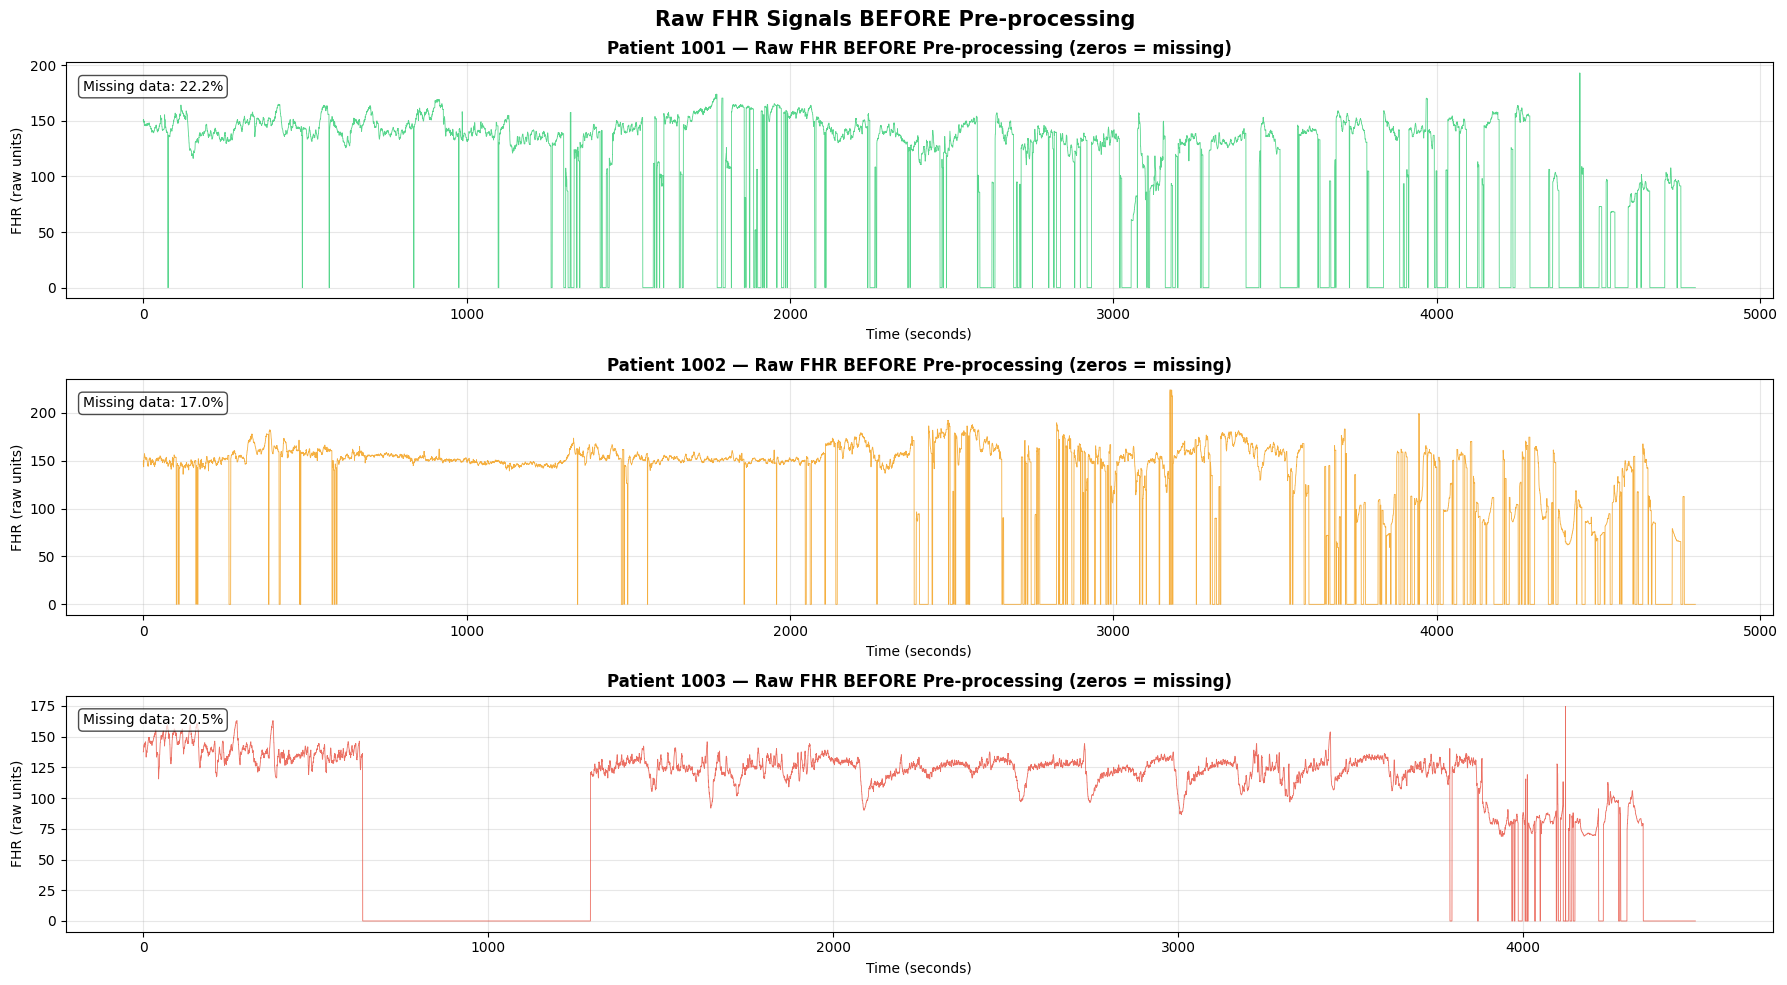

In [5]:
# ═══════════════════════════════════════════════════════
# VIZ 1: Raw Signal BEFORE Pre-processing
#         Shows raw FHR with zeros (missing data) for 3 patients
# ═══════════════════════════════════════════════════════
import random
label_df_temp = pd.read_csv(LABEL_CSV, dtype={'Patient_ID': str})
sample_pids   = label_df_temp['Patient_ID'].iloc[:3].tolist()

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
label_names = {0: 'Normal', 1: 'Suspect', 2: 'Pathologic'}

for i, pid in enumerate(sample_pids):
    record = wfdb.rdrecord(os.path.join(DATA_DIR, str(pid)))
    fhr_raw = record.p_signal[:, 0].astype(float)
    fs      = int(record.fs)
    t       = np.arange(len(fhr_raw)) / fs
    axes[i].plot(t, fhr_raw, color=colors[i], linewidth=0.6, alpha=0.8)
    axes[i].set_title(f'Patient {pid} — Raw FHR BEFORE Pre-processing (zeros = missing)',
                      fontweight='bold')
    axes[i].set_ylabel('FHR (raw units)')
    axes[i].set_xlabel('Time (seconds)')
    axes[i].grid(True, alpha=0.3)
    zero_pct = 100 * np.sum(fhr_raw == 0) / len(fhr_raw)
    axes[i].annotate(f'Missing data: {zero_pct:.1f}%', xy=(0.01, 0.88),
                     xycoords='axes fraction', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Raw FHR Signals BEFORE Pre-processing', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_raw_before_preproc.png'), dpi=150)
plt.show()


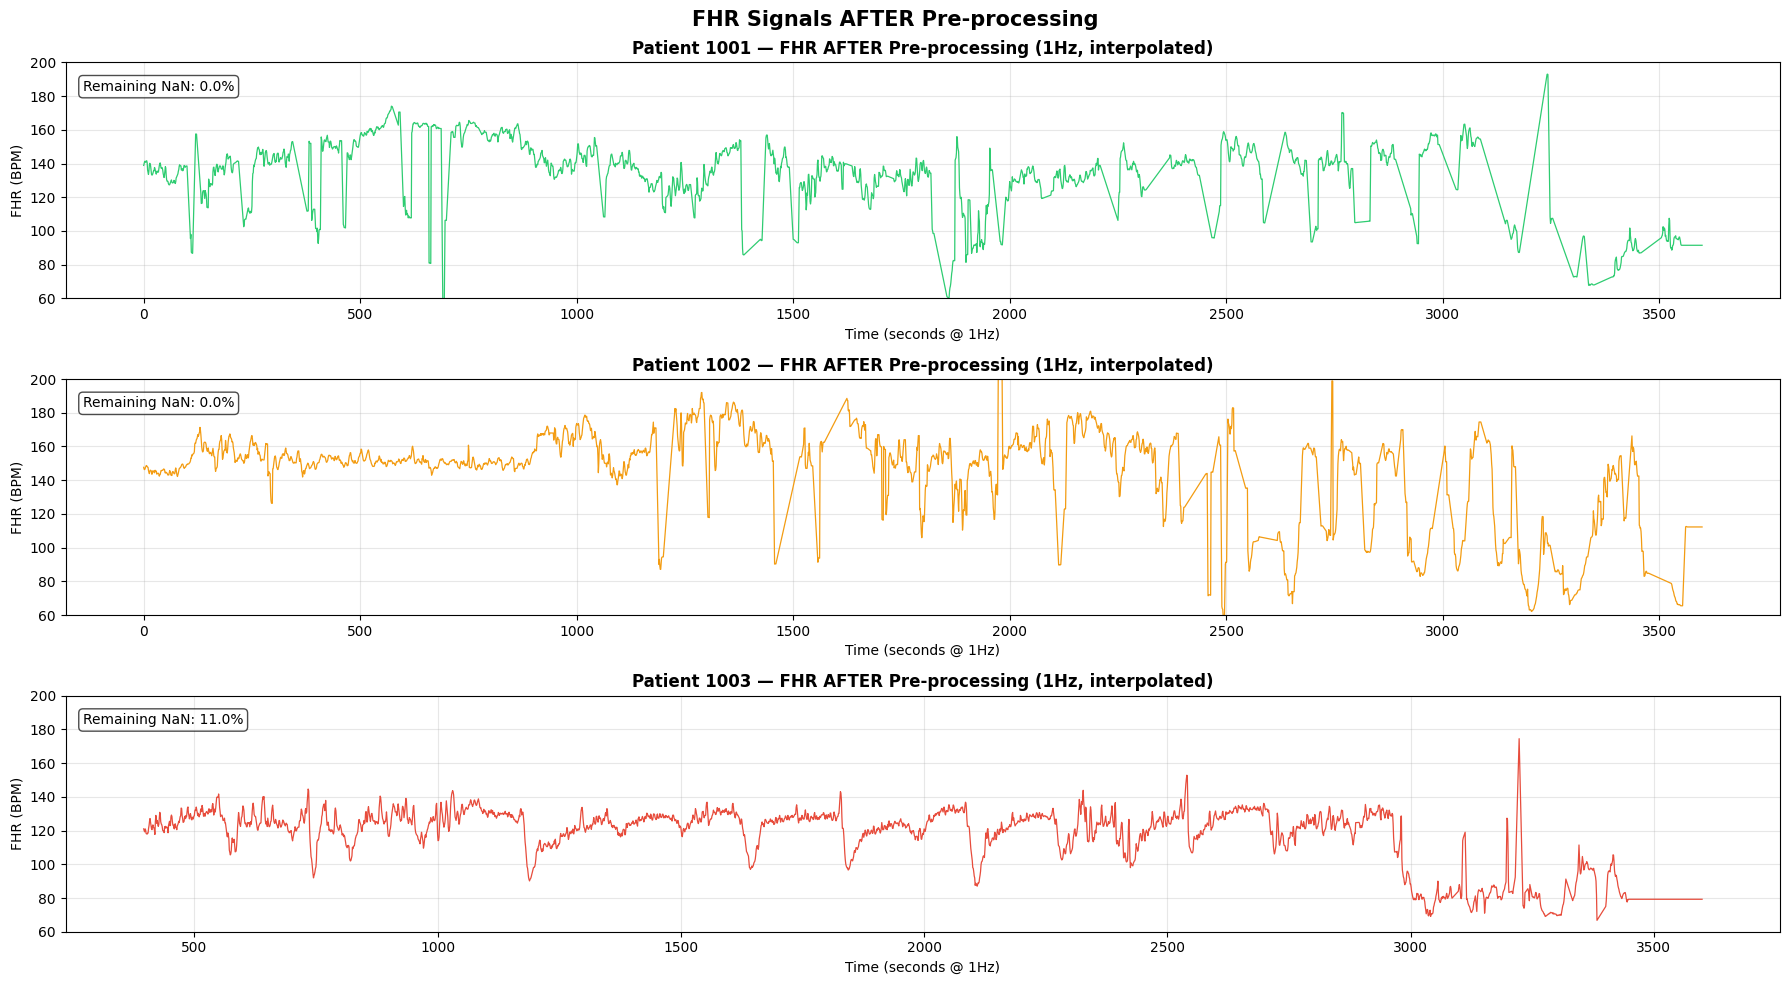

In [6]:
# ═══════════════════════════════════════════════════════
# VIZ 2: Signal AFTER Pre-processing (1Hz, interpolated, no zeros)
#         Same 3 patients as above
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=False)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for i, pid in enumerate(sample_pids):
    fhr_clean, uc_clean = prepare_signal(pid)
    if fhr_clean is None:
        axes[i].set_title(f'Patient {pid} — No valid segment found')
        continue
    t = np.arange(len(fhr_clean))
    axes[i].plot(t, fhr_clean, color=colors[i], linewidth=0.9)
    axes[i].set_title(f'Patient {pid} — FHR AFTER Pre-processing (1Hz, interpolated)',
                      fontweight='bold')
    axes[i].set_ylabel('FHR (BPM)')
    axes[i].set_xlabel('Time (seconds @ 1Hz)')
    axes[i].set_ylim(60, 200)
    axes[i].grid(True, alpha=0.3)
    nan_pct = 100 * np.sum(np.isnan(fhr_clean)) / len(fhr_clean)
    axes[i].annotate(f'Remaining NaN: {nan_pct:.1f}%', xy=(0.01, 0.88),
                     xycoords='axes fraction', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('FHR Signals AFTER Pre-processing', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_clean_after_preproc.png'), dpi=150)
plt.show()


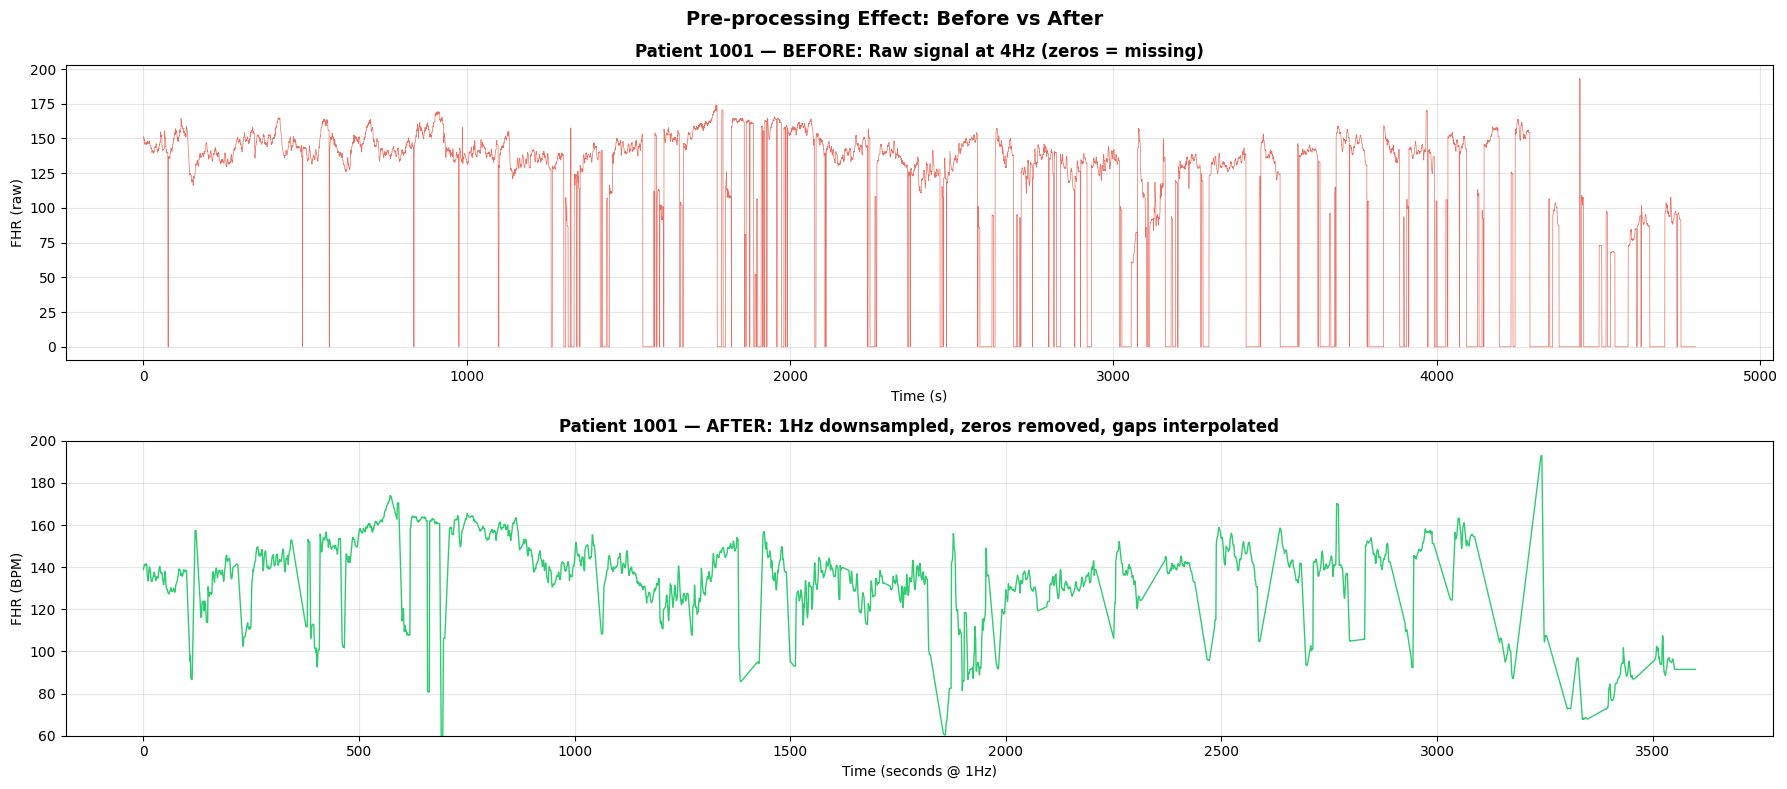

In [7]:
# ═══════════════════════════════════════════════════════
# VIZ 3: Before vs After — Side-by-side comparison (1 patient)
# ═══════════════════════════════════════════════════════
pid   = sample_pids[0]
record   = wfdb.rdrecord(os.path.join(DATA_DIR, str(pid)))
fhr_raw  = record.p_signal[:, 0].astype(float)
fs_orig  = int(record.fs)
t_raw    = np.arange(len(fhr_raw)) / fs_orig

fhr_clean, _ = prepare_signal(pid)
t_clean      = np.arange(len(fhr_clean)) if fhr_clean is not None else []

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=False)

axes[0].plot(t_raw, fhr_raw, color='#e74c3c', linewidth=0.5, alpha=0.8)
axes[0].set_title(f'Patient {pid} — BEFORE: Raw signal at {fs_orig}Hz (zeros = missing)',
                  fontweight='bold')
axes[0].set_ylabel('FHR (raw)')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, alpha=0.3)

if fhr_clean is not None:
    axes[1].plot(t_clean, fhr_clean, color='#2ecc71', linewidth=1.0)
    axes[1].set_title(f'Patient {pid} — AFTER: 1Hz downsampled, zeros removed, gaps interpolated',
                      fontweight='bold')
    axes[1].set_ylabel('FHR (BPM)')
    axes[1].set_xlabel('Time (seconds @ 1Hz)')
    axes[1].set_ylim(60, 200)
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Pre-processing Effect: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_before_vs_after_preproc.png'), dpi=150)
plt.show()


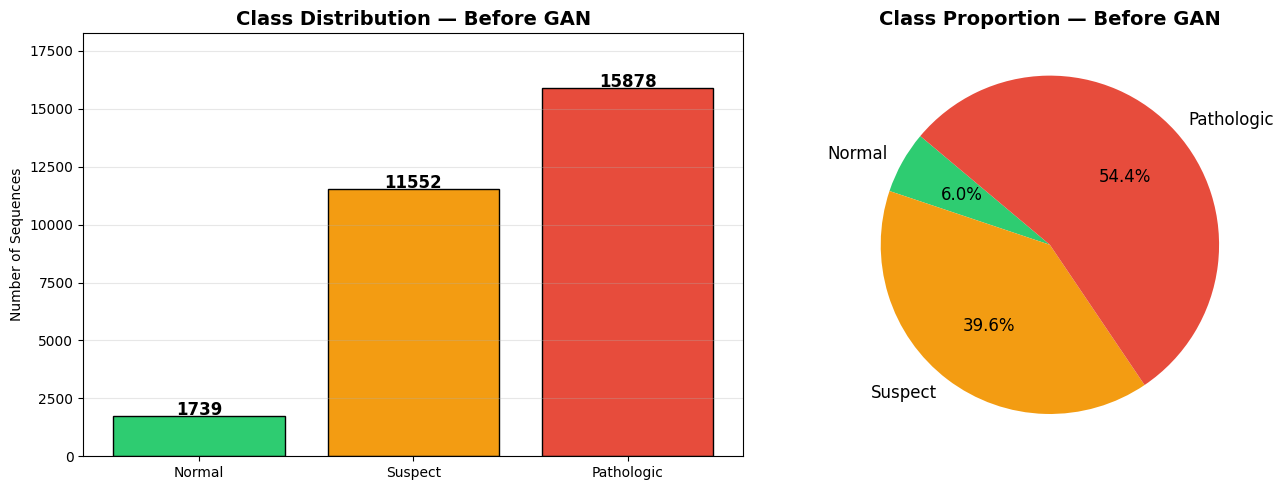

Normal: 1739 | Suspect: 11552 | Pathologic: 15878


In [8]:
# ═══════════════════════════════════════════════════════
# VIZ 4: Class Distribution Before GAN
# ═══════════════════════════════════════════════════════
labels_map = {0: 'Normal', 1: 'Suspect', 2: 'Pathologic'}
counts     = [int(np.sum(y_seq == i)) for i in range(3)]
colors     = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(list(labels_map.values()), counts, color=colors, edgecolor='black')
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution — Before GAN', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Sequences')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie(counts, labels=list(labels_map.values()), colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion — Before GAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_class_before_gan.png'), dpi=150)
plt.show()
print(f"Normal: {counts[0]} | Suspect: {counts[1]} | Pathologic: {counts[2]}")


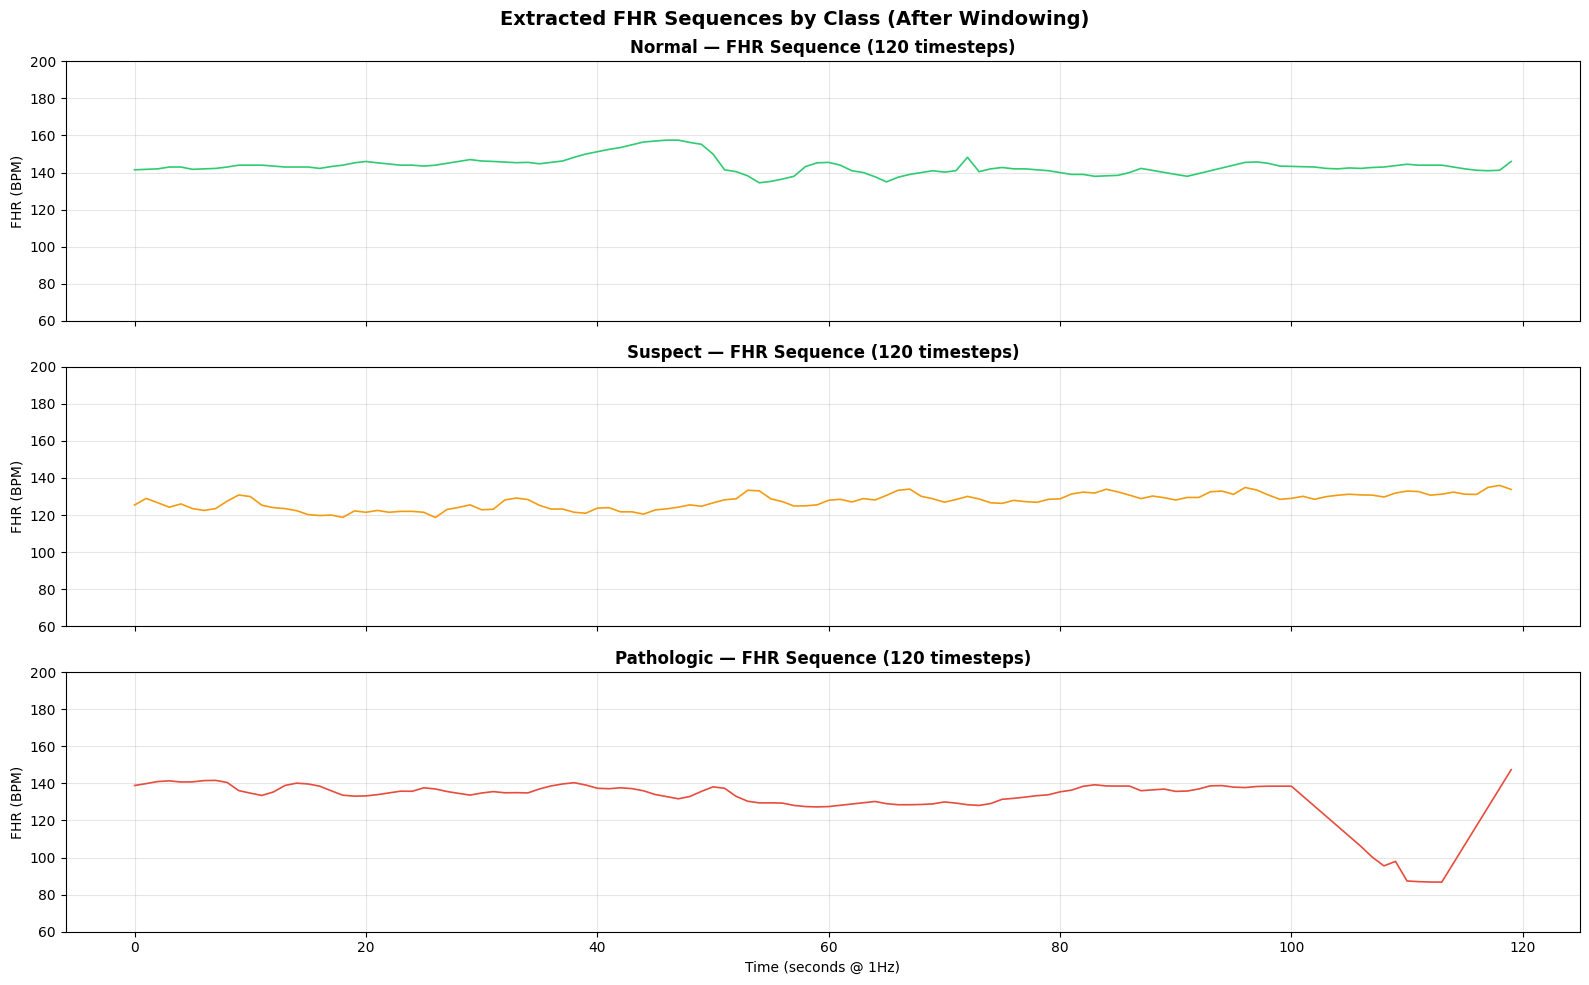

In [9]:
# ═══════════════════════════════════════════════════════
# VIZ 5: One FHR sequence per class (120 timesteps)
# ═══════════════════════════════════════════════════════
class_names  = ['Normal', 'Suspect', 'Pathologic']
class_colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
for cls in range(3):
    idx     = np.where(y_seq == cls)[0][0]
    raw_bpm = scaler_fhr.inverse_transform(X_seq[idx].reshape(-1, 1)).flatten()
    axes[cls].plot(raw_bpm, color=class_colors[cls], linewidth=1.2)
    axes[cls].set_title(f'{class_names[cls]} — FHR Sequence (120 timesteps)', fontweight='bold')
    axes[cls].set_ylabel('FHR (BPM)')
    axes[cls].set_ylim(60, 200)
    axes[cls].grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (seconds @ 1Hz)')
plt.suptitle('Extracted FHR Sequences by Class (After Windowing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_seq_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()


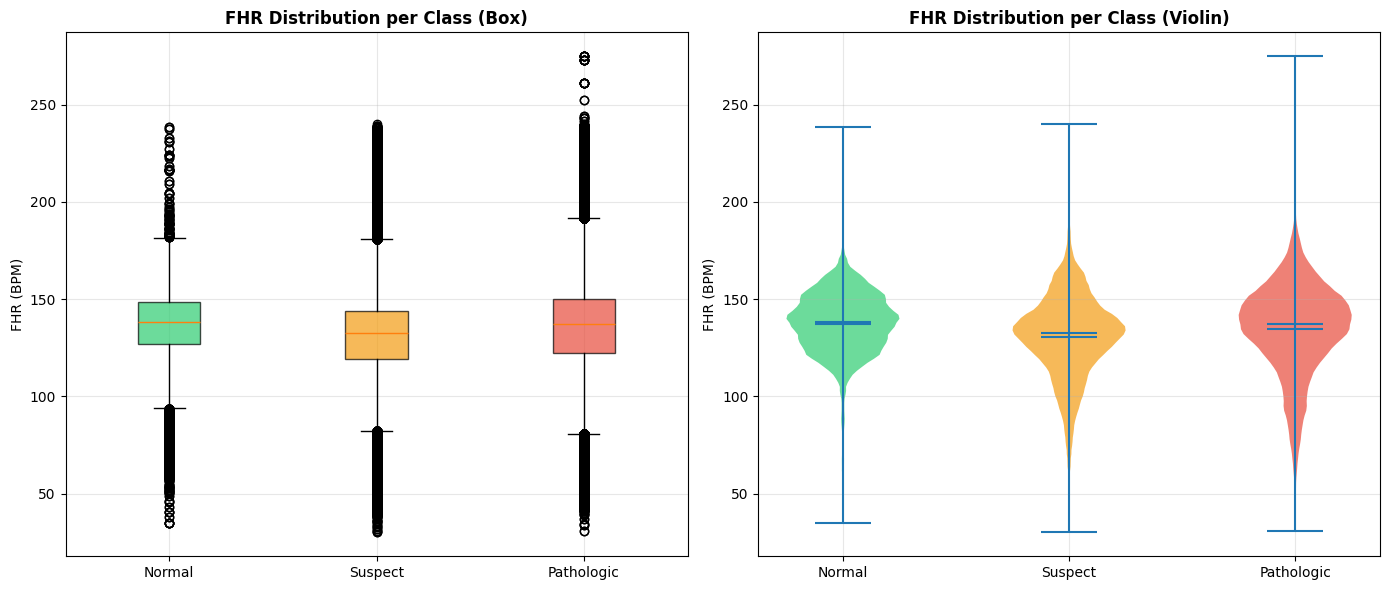

In [10]:
# ═══════════════════════════════════════════════════════
# VIZ 6: FHR Distribution per Class — Box + Violin
# ═══════════════════════════════════════════════════════
class_names = ['Normal', 'Suspect', 'Pathologic']
colors      = ['#2ecc71', '#f39c12', '#e74c3c']

bpm_by_class = []
for cls in range(3):
    seqs = X_seq[y_seq == cls]
    bpm  = scaler_fhr.inverse_transform(seqs.reshape(-1, 1)).flatten()
    bpm_by_class.append(bpm)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bp = axes[0].boxplot(bpm_by_class, patch_artist=True, labels=class_names)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('FHR Distribution per Class (Box)', fontweight='bold')
axes[0].set_ylabel('FHR (BPM)'); axes[0].grid(True, alpha=0.3)

parts = axes[1].violinplot(bpm_by_class, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_alpha(0.7)
axes[1].set_xticks([1, 2, 3]); axes[1].set_xticklabels(class_names)
axes[1].set_title('FHR Distribution per Class (Violin)', fontweight='bold')
axes[1].set_ylabel('FHR (BPM)'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_fhr_dist_class.png'), dpi=150)
plt.show()


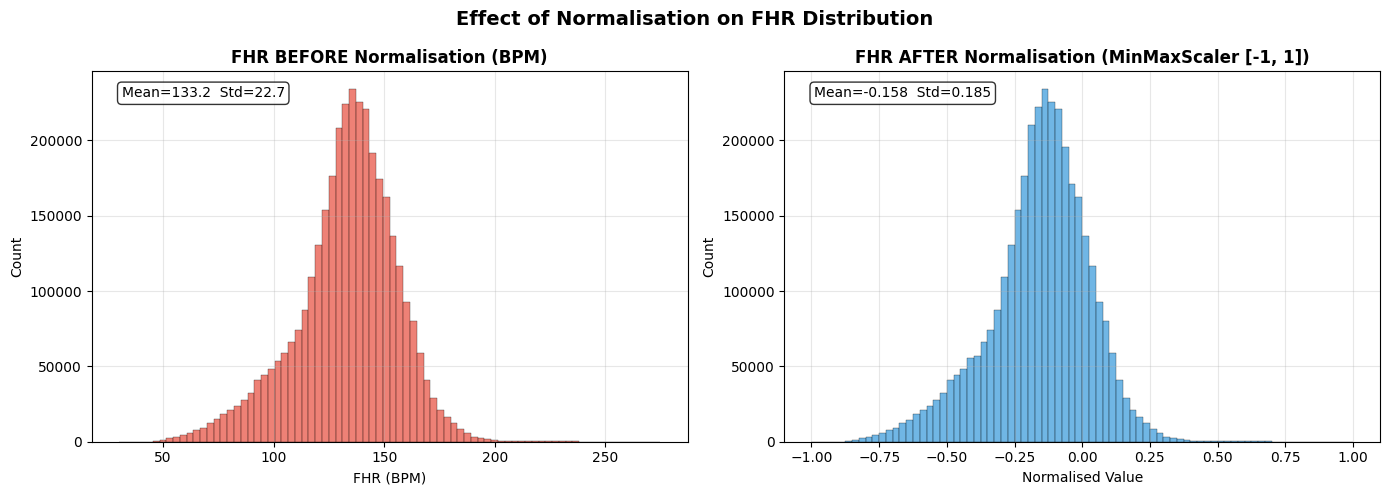

In [11]:
# ═══════════════════════════════════════════════════════
# VIZ 7: Normalisation Effect — Before vs After MinMaxScaler
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before normalisation — raw BPM
bpm_raw = scaler_fhr.inverse_transform(X_seq.reshape(-1, 1)).flatten()
axes[0].hist(bpm_raw, bins=80, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_title('FHR BEFORE Normalisation (BPM)', fontweight='bold')
axes[0].set_xlabel('FHR (BPM)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Mean={bpm_raw.mean():.1f}  Std={bpm_raw.std():.1f}',
                 xy=(0.05, 0.93), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# After normalisation — [-1, 1]
norm_flat = X_seq.flatten()
axes[1].hist(norm_flat, bins=80, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].set_title('FHR AFTER Normalisation (MinMaxScaler [-1, 1])', fontweight='bold')
axes[1].set_xlabel('Normalised Value')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f'Mean={norm_flat.mean():.3f}  Std={norm_flat.std():.3f}',
                 xy=(0.05, 0.93), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Effect of Normalisation on FHR Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_normalisation_effect.png'), dpi=150)
plt.show()


## MODULE 2 — LSTM Autoencoder: Build & Train

In [ ]:
# ═══════════════════════════════════════════════════════
# MODULE 2A: BUILD LSTM AUTOENCODER
# ═══════════════════════════════════════════════════════
print(">>> Building LSTM Autoencoder...")
inputs = Input(shape=(SEQ_LEN, 1))

# Encoder
encoded = LSTM(64, return_sequences=True)(inputs)
encoded = LSTM(32, return_sequences=False)(encoded)
latent  = Dense(LATENT_DIM, activation='tanh', name='latent_space')(encoded)

# Decoder
    decoded = RepeatVector(SEQ_LEN)(latent)
    decoded = LSTM(32, return_sequences=True)(decoded)
    decoded = LSTM(64, return_sequences=True)(decoded)
    outputs = TimeDistributed(Dense(1, activation='tanh'))(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()


>>> Building LSTM Autoencoder...


I0000 00:00:1774961552.802115      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 120, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 120, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 120, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,585 (248.38 KB)

 Trainable params: 63,585 (248.38 KB)

 Non-trainable params: 0 (0.00 B)

>>> Training LSTM Autoencoder...
Epoch 1/30


I0000 00:00:1774961563.533003      81 cuda_dnn.cc:529] Loaded cuDNN version 91002


388/388 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - loss: 0.0180 - val_loss: 0.0125
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0130 - val_loss: 0.0107
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0102 - val_loss: 0.0069
Epoch 4/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0071 - val_loss: 0.0056
Epoch 5/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0060 - val_loss: 0.0049
Epoch 6/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0052 - val_loss: 0.0055
Epoch 7/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 8/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 9/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0041 - val_loss: 0.0035
Epoch 10/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 11/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 12/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 

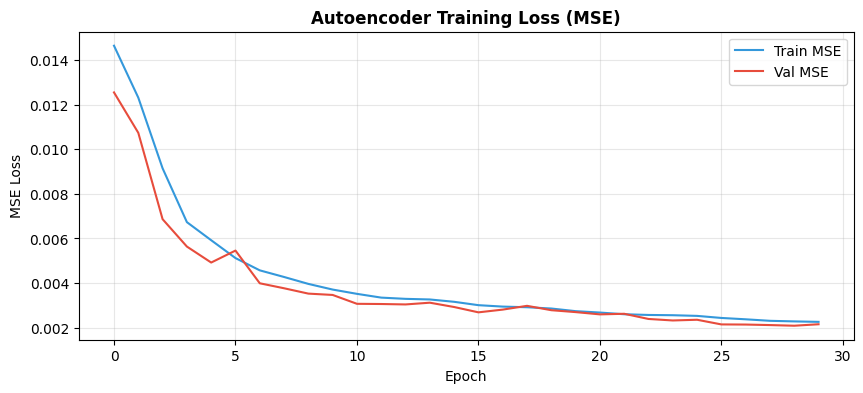

Final Train MSE : 0.002262
Final Val   MSE : 0.002155


In [13]:
# ═══════════════════════════════════════════════════════
# MODULE 2B: TRAIN LSTM AUTOENCODER
# ═══════════════════════════════════════════════════════
print(">>> Training LSTM Autoencoder...")
history = autoencoder.fit(
    X_seq, X_seq,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train MSE', color='#3498db')
plt.plot(history.history['val_loss'], label='Val MSE',   color='#e74c3c')
plt.title('Autoencoder Training Loss (MSE)', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_loss.png'), dpi=150)
plt.show()

final_train = history.history['loss'][-1]
final_val   = history.history['val_loss'][-1]
print(f"Final Train MSE : {final_train:.6f}")
print(f"Final Val   MSE : {final_val:.6f}")


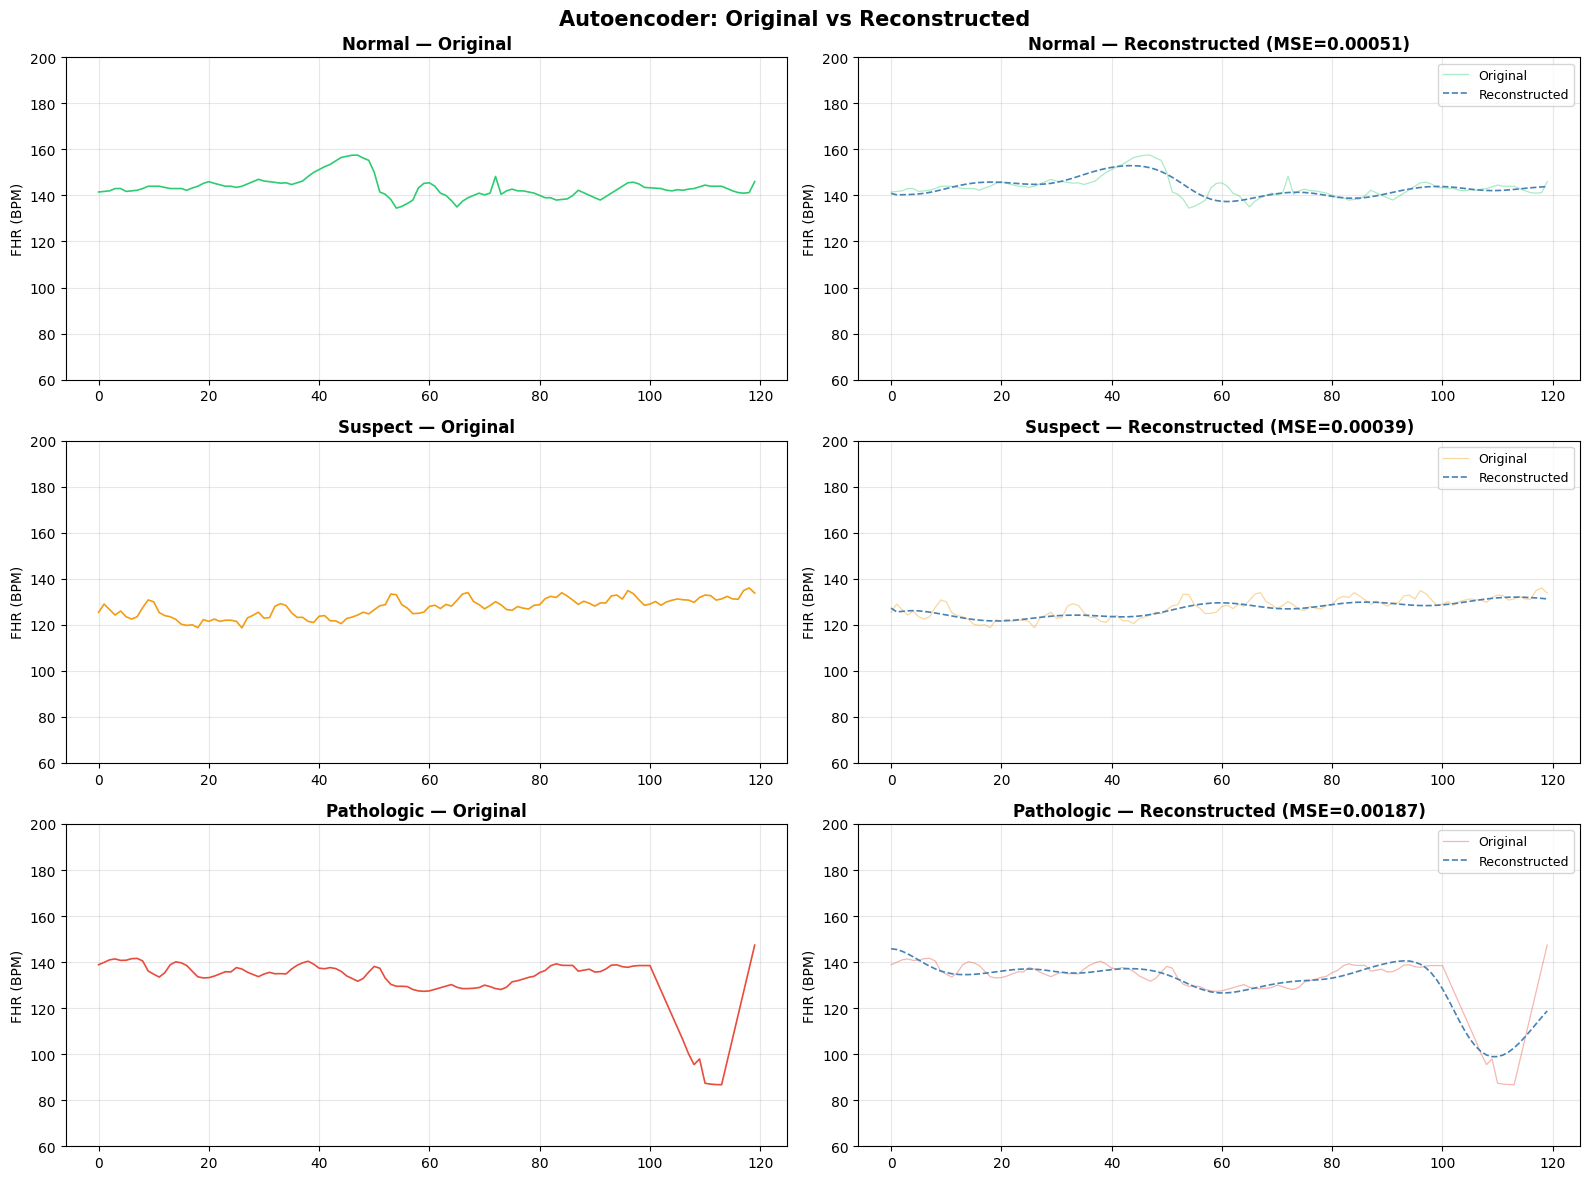

In [14]:
# ═══════════════════════════════════════════════════════
# MODULE 2C: AE RECONSTRUCTION — Before vs After
# ═══════════════════════════════════════════════════════
class_names  = ['Normal', 'Suspect', 'Pathologic']
class_colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for row, cls in enumerate(range(3)):
    idx       = np.where(y_seq == cls)[0][0]
    original  = X_seq[idx]
    recon     = autoencoder.predict(original[np.newaxis], verbose=0)[0]
    mse       = float(np.mean((original - recon) ** 2))
    orig_bpm  = scaler_fhr.inverse_transform(original.reshape(-1, 1)).flatten()
    recon_bpm = scaler_fhr.inverse_transform(recon.reshape(-1, 1)).flatten()

    axes[row, 0].plot(orig_bpm, color=class_colors[cls], linewidth=1.2)
    axes[row, 0].set_title(f'{class_names[cls]} — Original', fontweight='bold')
    axes[row, 0].set_ylabel('FHR (BPM)'); axes[row, 0].set_ylim(60, 200)
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(orig_bpm,  color=class_colors[cls], linewidth=0.9, alpha=0.4, label='Original')
    axes[row, 1].plot(recon_bpm, color='steelblue', linewidth=1.2, linestyle='--', label='Reconstructed')
    axes[row, 1].set_title(f'{class_names[cls]} — Reconstructed (MSE={mse:.5f})', fontweight='bold')
    axes[row, 1].set_ylabel('FHR (BPM)'); axes[row, 1].set_ylim(60, 200)
    axes[row, 1].legend(fontsize=9); axes[row, 1].grid(True, alpha=0.3)

plt.suptitle('Autoencoder: Original vs Reconstructed', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_ae_reconstruction.png'), dpi=150)
plt.show()


In [ ]:
# The overlap between classes in the latent space is expected due to the inherent physiological similarity between CTG signal patterns, especially between normal, suspect, and pathological conditions.

The autoencoder achieves strong reconstruction performance because it learns the underlying temporal structure common across all CTG signals. Since reconstruction is a self-supervised task that does not require class discrimination, the model can accurately reproduce signals even when latent representations of different classes overlap

>>> Extracting Latent Space...
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


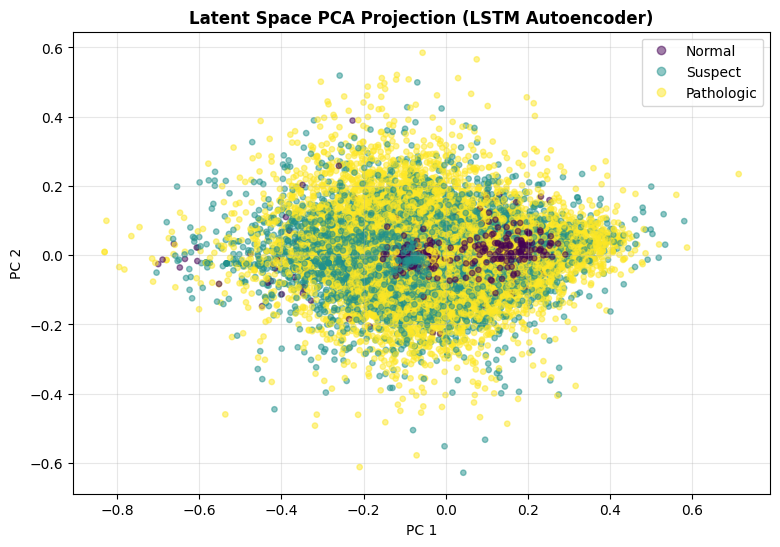

Latent vectors shape : (29169, 32)
PC1 variance explained: 46.2%
PC2 variance explained: 13.9%


In [15]:
# ═══════════════════════════════════════════════════════
# MODULE 2D: LATENT SPACE PCA PROJECTION
# ═══════════════════════════════════════════════════════
print(">>> Extracting Latent Space...")
encoder = Model(inputs, latent)
Z       = encoder.predict(X_seq, batch_size=256)

pca   = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=y_seq, cmap='viridis', alpha=0.5, s=15)
plt.title('Latent Space PCA Projection (LSTM Autoencoder)', fontweight='bold')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Normal', 'Suspect', 'Pathologic'])
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_latent_pca.png'), dpi=150)
plt.show()

print(f"Latent vectors shape : {Z.shape}")
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%")


Running t-SNE on latent vectors (this may take ~30s)...


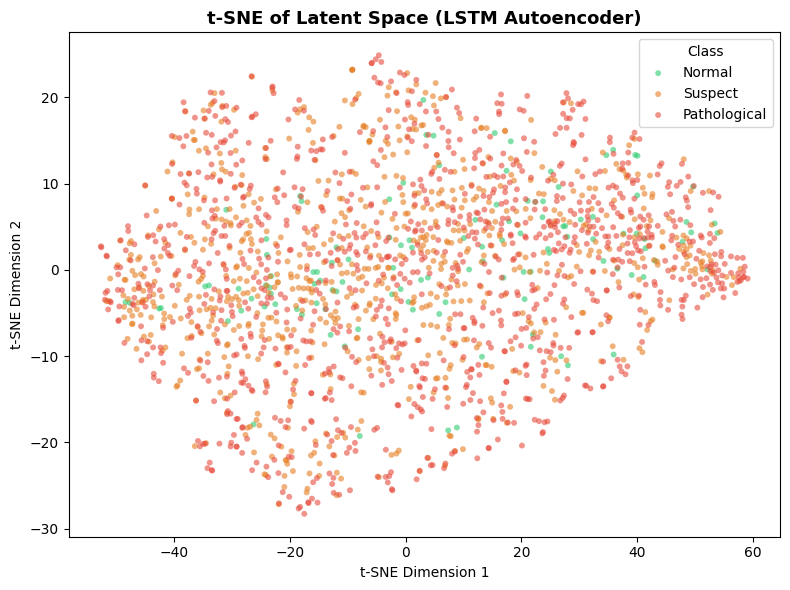

✓ t-SNE plot saved.


In [16]:
# ═══════════════════════════════════════════════════════
# VIZ: t-SNE of Latent Space (Normal vs Other classes)
# ═══════════════════════════════════════════════════════
from sklearn.manifold import TSNE

print("Running t-SNE on latent vectors (this may take ~30s)...")

MAX_SAMPLES = 2000
idx   = np.random.choice(len(Z), min(MAX_SAMPLES, len(Z)), replace=False)
Z_sub = Z[idx]
y_sub = y_seq[idx]   # ← fixed: y_seq instead of y_seq_all

tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
Z_2d = tsne.fit_transform(Z_sub)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#2ecc71', 1: '#e67e22', 2: '#e74c3c'}
labels = {0: 'Normal', 1: 'Suspect', 2: 'Pathological'}

for cls in [0, 1, 2]:
    mask = y_sub == cls
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=colors[cls], label=labels[cls],
               alpha=0.6, s=18, edgecolors='none')

ax.set_title('t-SNE of Latent Space (LSTM Autoencoder)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Class', framealpha=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_latent.png'), dpi=150)
plt.show()
print("✓ t-SNE plot saved.")

## MODULE 3 — AE-GAN: Parameter Tuning & Training

In [ ]:
# ═══════════════════════════════════════════════════════
# MODULE 3A: ENCODE NORMAL LATENTS + PARAMETER GRID SEARCH
#
# WHAT IS TUNED (via dictionary):
#   - d_lr          : Discriminator learning rate
#   - g_lr          : Generator learning rate
#   - noise_std     : Input noise perturbation on D training
#   - fm_weight     : Feature matching loss weight
#   - g_steps       : Generator updates per epoch
#   - dropout_rate  : Dropout in discriminator
#   - g_hidden      : Generator hidden layer size
#   - d_hidden      : Discriminator hidden layer size
#
# SCORING: score = |D_Acc - 0.5| + |Std_ratio - 1.0|  (lower = better)
# ═══════════════════════════════════════════════════════

# ── Encode Normal latent vectors ──
encoder_model = Model(inputs, latent)
Z_all   = encoder_model.predict(X_seq, batch_size=256, verbose=0) # convert all sequences to latent space
Z_train = Z_all[y_seq == 0] # only use normal class latents for GAN training

Z_mean  = np.mean(Z_train, axis=0) # compute mean of normal latents for later re-scaling
Z_std   = np.std(Z_train,  axis=0) + 1e-8 # add small value to prevent division by zero
Z_train = (Z_train - Z_mean) / Z_std # standardize to zero mean and unit variance for stable GAN training       

real_std_bpm = float(np.std(
    scaler_fhr.inverse_transform(X_seq[y_seq == 0].reshape(-1, 1)) # whats is this? It converts the normalized latent vectors back to BPM scale to compute the real standard deviation of the normal FHR sequences, which serves as a target for the GAN to match in terms of variability.
))
print(f"Normal latent vectors : {Z_train.shape}")
print(f"Real Normal FHR Std   : {real_std_bpm:.2f} BPM  ← target to match")

# ── Build decoder helper ──
def build_decoder():
    idx    = next(i for i, l in enumerate(autoencoder.layers) if l.name == 'latent_space')
    dec_in = Input(shape=(LATENT_DIM,))
    x      = dec_in
    for layer in autoencoder.layers[idx + 1:]:
        x = layer(x)
    return Model(dec_in, x)

# ── Architecture builders using dict config ──
def build_generator_from_config(cfg):
    h = cfg['g_hidden']
    return Sequential([
        Dense(h * 4, input_dim=LATENT_DIM), LeakyReLU(0.2),
        Dense(h * 4),                        LeakyReLU(0.2),
        Dense(h * 2),                        LeakyReLU(0.2),
        Dense(h),                            LeakyReLU(0.2),
        Dense(LATENT_DIM, activation='tanh') # tanh final activation: Your real latents were standardized to roughly [-1, 1] range. tanh forces the Generator's output into exactly that range, ensuring it speaks the same "language" as real data.
    ], name='Generator') # why tanh? Because it outputs in the range [-1, 1], which can help stabilize training and prevent issues with vanishing/exploding gradients. By scaling the output to match the range of the real latent vectors, we can improve convergence and model performance.

def build_discriminator_from_config(cfg):
    h  = cfg['d_hidden']
    dr = cfg['dropout_rate']
    m  = Sequential([
        tf.keras.layers.GaussianNoise(0.05),
        Dense(h * 2, input_dim=LATENT_DIM), LeakyReLU(0.2), Dropout(dr),
        Dense(h),                            LeakyReLU(0.2), Dropout(dr),
        Dense(1, activation='sigmoid')
    ], name='Discriminator')
    m.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=cfg['d_lr'], beta_1=0.5, clipnorm=1.0),
              metrics=['accuracy'])
    return m

# ── Single trial function ──
def run_trial(cfg, epochs=1500):
    gen   = build_generator_from_config(cfg)
    disc  = build_discriminator_from_config(cfg)
    g_opt = Adam(learning_rate=cfg['g_lr'], beta_1=0.5, clipnorm=1.0)
    bce   = tf.keras.losses.BinaryCrossentropy()
    half  = BATCH_SIZE // 2
    d_accs, d_ls, g_ls = [], [], []

    for epoch in range(epochs):
        # Train Discriminator
        idx_r  = np.random.randint(0, Z_train.shape[0], half) 
        # prevent overpowering D by adding noise to real latents and input noise for fake latents. This encourages D to learn more robust features and prevents it from dominating G, which can lead to better overall GAN performance and stability.
        real_z = Z_train[idx_r] + np.random.normal(0, 0.02, (half, LATENT_DIM)) # add small noise to real latents to make D less confident and improve generalization. This technique, known as label smoothing or noisy labels, can help prevent the discriminator from becoming too strong and dominating the generator during training.
        noise  = np.random.normal(0, 1, (half, LATENT_DIM))
        noise += np.random.normal(0, cfg['noise_std'], (half, LATENT_DIM)) # noise_std is a hyperparameter that controls the amount of random perturbation added to the input noise for generating fake samples. By tuning this parameter, we can encourage the generator to produce more diverse and robust samples, which can help improve GAN training stability and prevent issues like mode collapse.  
        fake_z = gen(noise, training=False).numpy() # input noise with extra perturbation, output fake latents, a random vector in latent space that the generator transforms into a fake sample. We add noise to the input to encourage the generator to produce more robust and varied outputs, which can help prevent overfitting and mode collapse.
        fake_z += np.random.normal(0, 0.02, fake_z.shape) # add small noise to fake latents to make D's job harder and encourage it to learn more general features rather than memorizing specific samples.
        dr = disc.train_on_batch(real_z, np.ones((half, 1)) * 0.95) # use soft labels (0.95 instead of 1.0) for real samples to prevent D from becoming too confident, which can improve GAN training stability and help the generator learn better.
        df = disc.train_on_batch(fake_z, np.zeros((half, 1))) # train D to classify fake samples as 0 (fake)
        d_loss = 0.5 * np.add(dr, df) # average real and fake losses for reporting

        # Train Generator
        g_ep = 0.0
        for _ in range(cfg['g_steps']):
            nt = tf.convert_to_tensor(
                np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM)), dtype=tf.float32)
            with tf.GradientTape() as tape:
                fzg   = gen(nt, training=True) # forward pass through generator to get fake latents
                fpred = disc(fzg, training=False) # get discriminator's prediction on fake latents (probability of being real), descriminator is frozen during generator training to provide a stable learning signal, allowing the generator to focus on improving its output without the discriminator's weights changing simultaneously, which can lead to more stable GAN training.
                ri    = np.random.randint(0, Z_train.shape[0], BATCH_SIZE) # randomly select real latents for feature matching
                xr    = tf.convert_to_tensor(Z_train[ri], dtype=tf.float32) # real latents for feature matching
                xf    = fzg # fake latents for feature matching
                for layer in disc.layers[:-1]: # extract features from all layers except the final output layer for feature matching loss , extracting internal features from the discriminator allows us to compute a feature matching loss, which encourages the generator to produce samples that not only fool the discriminator but also match the internal representations of real data, leading to more realistic and stable generated samples.
                    xr = layer(xr); xf = layer(xf) # pass real and fake latents through discriminator layers to get feature representations
                fm  = tf.reduce_mean(tf.square(xr - xf)) # feature matching loss: mean squared error between real and fake features, encourages the generator to produce samples that match the internal representations of real data in the discriminator, leading to more realistic and stable generated samples.
                # Generator must produce samples that look similar internally, not just fool output
                glv = bce(tf.ones_like(fpred), fpred) + cfg['fm_weight'] * fm # total generator loss = adversarial loss + feature matching loss, balancing these two components encourages the generator to produce samples that not only fool the discriminator but also match the internal representations of real data, leading to more realistic and stable generated samples.
            grads = tape.gradient(glv, gen.trainable_variables) # compute gradients of generator loss with respect to generator weights
            g_opt.apply_gradients(zip(grads, gen.trainable_variables)) # update generator weights based on total loss
            g_ep += float(glv)

        d_accs.append(float(d_loss[1])) # discriminator accuracy for this epoch, used to compute mean accuracy over last 200 epochs for scoring. A discriminator accuracy close to 0.5 indicates that the discriminator is unable to distinguish real from fake samples, which is a sign of good GAN convergence.
        d_ls.append(float(d_loss[0]))
        g_ls.append(g_ep / cfg['g_steps'])

    # Score — pure GAN, no manual noise
    mean_d_acc = float(np.mean(d_accs[-200:]))# average discriminator accuracy over last 200 epochs to assess convergence (should be around 0.5 for a good GAN)
    dec        = build_decoder() # build decoder model to convert latent vectors back to FHR sequences for evaluation
    noise_eval = np.random.normal(0, 1, (100, LATENT_DIM)) # generate 100 fake latent vectors from pure noise (no extra perturbation) to evaluate the quality of generated samples in terms of their statistical properties compared to real data.
    fake_lat_e = gen.predict(noise_eval, verbose=0) * Z_std + Z_mean # scale generated latents back to original distribution using mean and std of real latents, ensuring that the generated samples are in the same range and distribution as the real data for a fair evaluation.
    fake_seq_e = dec.predict(fake_lat_e, verbose=0) # decode generated latents back to FHR sequences using the decoder, allowing us to evaluate the quality of the generated samples in terms of their statistical properties compared to real data.
    fake_bpm_e = scaler_fhr.inverse_transform(fake_seq_e.reshape(-1, 1)).flatten() # undo normalization to get generated FHR values in BPM scale for comparison with real FHR data, enabling us to compute the standard deviation ratio as part of the scoring metric.
    std_ratio  = float(np.std(fake_bpm_e)) / real_std_bpm # compute ratio of standard deviation of generated FHR to real normal FHR, assessing how well the GAN captures the variability of real data (a ratio close to 1.0 indicates good variability matching)
    score      = 2.0 * abs(mean_d_acc - 0.5) + abs(std_ratio - 1.0) # compute final score based on discriminator accuracy and standard deviation ratio, give more importance to gan score
    return score, mean_d_acc, std_ratio, gen, dec, d_ls, g_ls

# ── PARAMETER GRID (dictionary-based) ──
param_grid = [
    # Each entry is a config dict — all tunable params in one place
    {'d_lr': 2e-4, 'g_lr': 1e-4, 'noise_std': 0.08, 'fm_weight': 0.10,
     'g_steps': 1, 'dropout_rate': 0.3, 'g_hidden': 128, 'd_hidden': 64},

    {'d_lr': 2e-4, 'g_lr': 5e-5, 'noise_std': 0.10, 'fm_weight': 0.05,
     'g_steps': 2, 'dropout_rate': 0.4, 'g_hidden': 128, 'd_hidden': 64},

    {'d_lr': 1e-4, 'g_lr': 1e-4, 'noise_std': 0.05, 'fm_weight': 0.10,
     'g_steps': 1, 'dropout_rate': 0.3, 'g_hidden': 256, 'd_hidden': 128},

    {'d_lr': 3e-4, 'g_lr': 1e-4, 'noise_std': 0.10, 'fm_weight': 0.10,
     'g_steps': 1, 'dropout_rate': 0.4, 'g_hidden': 256, 'd_hidden': 128},

    {'d_lr': 2e-4, 'g_lr': 2e-4, 'noise_std': 0.08, 'fm_weight': 0.05,
     'g_steps': 2, 'dropout_rate': 0.3, 'g_hidden': 128, 'd_hidden': 128},

    {'d_lr': 1e-4, 'g_lr': 5e-5, 'noise_std': 0.05, 'fm_weight': 0.05,
     'g_steps': 1, 'dropout_rate': 0.3, 'g_hidden': 64,  'd_hidden': 64},

    # Trial 7: Weak D + strong G (bigger g_steps, big g_hidden)
    {"d_lr": 1e-4, "g_lr": 2e-4, "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 3, "dropout_rate": 0.5, "g_hidden": 256, "d_hidden": 64},

    # Trial 8: Very slow D-lr, fast G-lr (aggressive TTUR)
    {"d_lr": 5e-5, "g_lr": 2e-4, "noise_std": 0.08, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.4, "g_hidden": 256, "d_hidden": 64},

    # Trial 9: Max dropout on D + high noise (handicap discriminator heavily)
    {"d_lr": 1e-4, "g_lr": 1e-4, "noise_std": 0.15, "fm_weight": 0.10,
     "g_steps": 2, "dropout_rate": 0.6, "g_hidden": 256, "d_hidden": 64},

    # Trial 10: Tiny D, big G, 3 G-steps (most extreme D-weakening)
    {"d_lr": 5e-5, "g_lr": 1e-4, "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 3, "dropout_rate": 0.5, "g_hidden": 512, "d_hidden": 32},

    # Trial 11: Balanced lr, max noise + high dropout (noise regularises D)
    {"d_lr": 2e-4, "g_lr": 2e-4, "noise_std": 0.15, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.5, "g_hidden": 128, "d_hidden": 64},

    # Trial 12: Slower both, more G-steps — gentle regime
    {"d_lr": 1e-4, "g_lr": 5e-5, "noise_std": 0.12, "fm_weight": 0.10,
     "g_steps": 3, "dropout_rate": 0.5, "g_hidden": 128, "d_hidden": 64},

    # Trial 13: Near-equal lrs, very small D, big G (ultra-weak D)
    {"d_lr": 5e-5, "g_lr": 5e-5, "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 3, "dropout_rate": 0.6, "g_hidden": 512, "d_hidden": 32},

    # Trial 14: Balanced lrs + moderate noise — "safe bet" near best trial
    {"d_lr": 2e-4, "g_lr": 1e-4, "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.5, "g_hidden": 256, "d_hidden": 64},

    # Trial 15: bump g_lr slightly above d_lr — gentle TTUR nudge
    {"d_lr": 2e-4, "g_lr": 1.5e-4, "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.4, "g_hidden": 128, "d_hidden": 64},
    
    # Trial 16: same as best trial #2 but 1 more g_step
    {"d_lr": 2e-4, "g_lr": 5e-5,   "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 3, "dropout_rate": 0.4, "g_hidden": 128, "d_hidden": 64},
    
    # Trial 17: trial #2 config + bigger generator
    {"d_lr": 2e-4, "g_lr": 5e-5,   "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.4, "g_hidden": 256, "d_hidden": 64},
    
    # Trial 18: slightly higher dropout + more noise — keep D_Acc up
    {"d_lr": 2e-4, "g_lr": 1e-4,   "noise_std": 0.12, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.45, "g_hidden": 192, "d_hidden": 64},
    
    # Trial 19: trial #11 was close (D_Acc=0.326, std=0.490) — raise d_lr to recover D_Acc
    {"d_lr": 3e-4, "g_lr": 2e-4,   "noise_std": 0.12, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.4, "g_hidden": 128, "d_hidden": 64},
    
    # Trial 20: trial #5 pattern (D_Acc=0.370) + larger g_hidden to push std ratio up
    {"d_lr": 2e-4, "g_lr": 2e-4,   "noise_std": 0.10, "fm_weight": 0.05,
     "g_steps": 2, "dropout_rate": 0.35, "g_hidden": 256, "d_hidden": 128},
]

# ── Run grid search ──
print(f"\nRunning {len(param_grid)} trials...")
print(f"{'#':>3} | {'d_lr':>7} | {'g_lr':>7} | {'noise':>5} | {'fm':>5} | {'gs':>2} | {'dr':>4} | {'G_h':>4} | {'D_h':>4} | {'D_Acc':>6} | {'StdR':>6} | {'Score':>6}")
print("─" * 90)

results = []
for t, cfg in enumerate(param_grid):
    tf.random.set_seed(42 + t); np.random.seed(42 + t)
    sc, da, sr, gen_t, dec_t, dls, gls = run_trial(cfg)
    results.append((sc, da, sr, gen_t, dec_t, dls, gls, cfg))
    print(f"{t+1:>3} | {cfg['d_lr']:>7.0e} | {cfg['g_lr']:>7.0e} | "
          f"{cfg['noise_std']:>5.2f} | {cfg['fm_weight']:>5.3f} | {cfg['g_steps']:>2} | "
          f"{cfg['dropout_rate']:>4.1f} | {cfg['g_hidden']:>4} | {cfg['d_hidden']:>4} | "
          f"{da:>6.3f} | {sr:>6.3f} | {sc:>6.3f}")

# ── Select best ──
best = min(results, key=lambda x: x[0])
(best_score, best_d_acc, best_std_r,
 generator, decoder_model,
 best_d_losses, best_g_losses, best_cfg) = best

best_idx = results.index(best) + 1
print(f"\n{'='*50}")
print(f"  BEST TRIAL : #{best_idx}")
print(f"{'='*50}")
for k, v in best_cfg.items():
    print(f"  {k:15s} : {v}")
print(f"  {'D Acc':15s} : {best_d_acc:.3f}  (target: ~0.50)")
print(f"  {'Std ratio':15s} : {best_std_r:.3f}  (target: 0.8–1.2)")
print(f"  {'Score':15s} : {best_score:.3f}  (lower = better)")
print(f"{'='*50}")


Normal latent vectors : (1739, 32)
Real Normal FHR Std   : 16.55 BPM  ← target to match

Running 20 trials...
  # |    d_lr |    g_lr | noise |    fm | gs |   dr |  G_h |  D_h |  D_Acc |   StdR |  Score
──────────────────────────────────────────────────────────────────────────────────────────


I0000 00:00:1774961998.322750      25 service.cc:152] XLA service 0x1cb4f250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774961998.322807      25 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774962001.019923      25 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  1 |   2e-04 |   1e-04 |  0.08 | 0.100 |  1 |  0.3 |  128 |   64 |  0.394 |  0.398 |  0.814
  2 |   2e-04 |   5e-05 |  0.10 | 0.050 |  2 |  0.4 |  128 |   64 |  0.388 |  0.427 |  0.797
  3 |   1e-04 |   1e-04 |  0.05 | 0.100 |  1 |  0.3 |  256 |  128 |  0.309 |  0.398 |  0.985
  4 |   3e-04 |   1e-04 |  0.10 | 0.100 |  1 |  0.4 |  256 |  128 |  0.403 |  0.194 |  1.001
  5 |   2e-04 |   2e-04 |  0.08 | 0.050 |  2 |  0.3 |  128 |  128 |  0.366 |  0.754 |  0.513
  6 |   1e-04 |   5e-05 |  0.05 | 0.050 |  1 |  0.3 |   64 |   64 |  0.327 |  0.887 |  0.460
  7 |   1e-04 |   2e-04 |  0.10 | 0.050 |  3 |  0.5 |  256 |   64 |  0.301 |  0.466 |  0.932
  8 |   5e-05 |   2e-04 |  0.08 | 0.050 |  2 |  0.4 |  256 |   64 |  0.221 |  0.621 |  0.937
  9 |   1e-04 |   1e-04 |  0.15 | 0.100 |  2 |  0.6 |  256 |   64 |  0.222 |  0.190 |  1.366
 10 |   5e-05 |   1e-04 |  0.10 | 0.050 |  3 |  0.5 |  512 |   32 |  0.124 |  0.308 |  1.443
 11 |   2e-04 |   2e-04 |  0.15 | 0.050 |  2 |  0.5 |  128 |   64 |  0

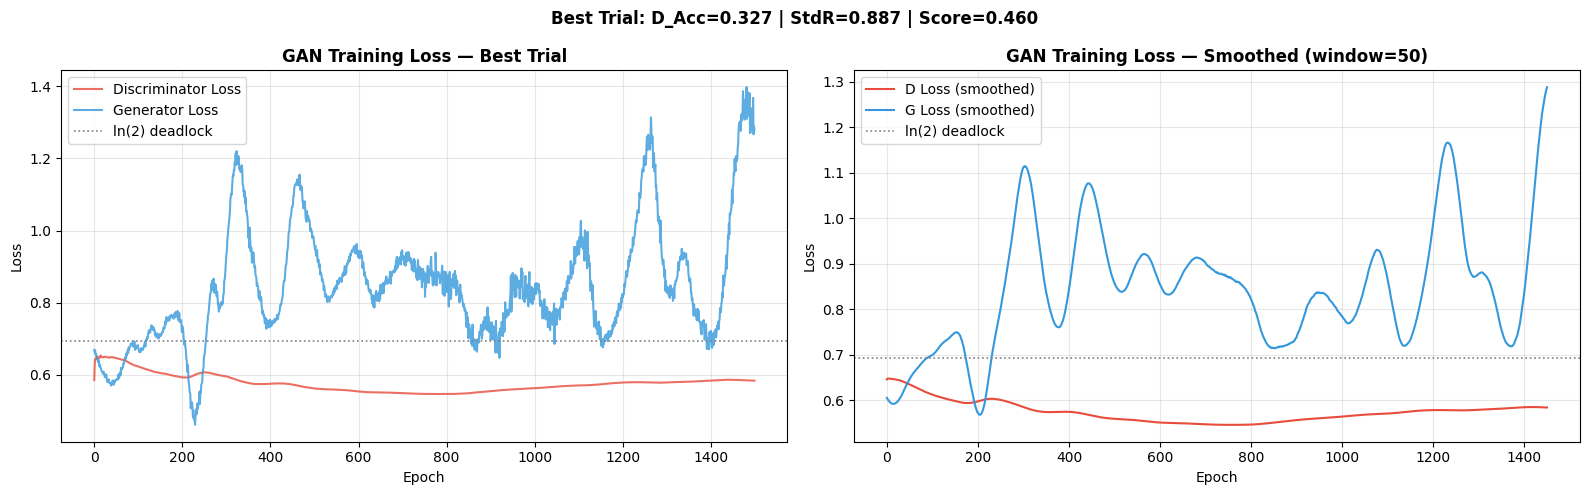

In [18]:
# ═══════════════════════════════════════════════════════
# MODULE 3B: BEST TRIAL — TRAINING DYNAMICS PLOT
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(best_d_losses, label='Discriminator Loss', color='#e74c3c', alpha=0.8)
axes[0].plot(best_g_losses, label='Generator Loss',     color='#3498db', alpha=0.8)
axes[0].axhline(0.693, color='gray', linestyle=':', linewidth=1.2, label='ln(2) deadlock')
axes[0].set_title('GAN Training Loss — Best Trial', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Smoothed view (moving average)
window = 50
d_smooth = np.convolve(best_d_losses, np.ones(window)/window, mode='valid')
g_smooth = np.convolve(best_g_losses, np.ones(window)/window, mode='valid')
axes[1].plot(d_smooth, label='D Loss (smoothed)', color='#e74c3c', linewidth=1.5)
axes[1].plot(g_smooth, label='G Loss (smoothed)', color='#3498db', linewidth=1.5)
axes[1].axhline(0.693, color='gray', linestyle=':', linewidth=1.2, label='ln(2) deadlock')
axes[1].set_title(f'GAN Training Loss — Smoothed (window={window})', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best Trial: D_Acc={best_d_acc:.3f} | StdR={best_std_r:.3f} | Score={best_score:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'aegan_loss.png'), dpi=150)
plt.show()


## MODULE 4 — Generate Balanced Data & Save

In [19]:
# ═══════════════════════════════════════════════════════
# MODULE 4A: GENERATE — Pure GAN (no manual noise)
# Normal = Suspect = Pathologic (match largest class)
# ═══════════════════════════════════════════════════════

n_suspect    = int(np.sum(y_seq == 1))
n_patho      = int(np.sum(y_seq == 2))
n_normal_real = int(np.sum(y_seq == 0))
target        = max(n_suspect, n_patho)
n_to_generate = target - n_normal_real

print("=" * 52)
print("  GENERATION PLAN")
print("=" * 52)
print(f"  Suspect count     : {n_suspect}")
print(f"  Pathologic count  : {n_patho}")
print(f"  Target per class  : {target}")
print(f"  Real Normal       : {n_normal_real}")
print(f"  To generate       : {n_to_generate} synthetic Normal")
print("=" * 52)

# ── Pure GAN generation ──
noise_in     = np.random.normal(0, 1, (n_to_generate, LATENT_DIM))
fake_latents = generator.predict(noise_in, batch_size=256, verbose=1)
fake_latents = fake_latents * Z_std + Z_mean
fake_seqs    = decoder_model.predict(fake_latents, batch_size=256, verbose=1)

print(f"\nGenerated shape : {fake_seqs.shape}")

# ── Metrics ──
real_bpm_m = scaler_fhr.inverse_transform(X_seq[y_seq == 0].reshape(-1, 1)).flatten()
fake_bpm_m = scaler_fhr.inverse_transform(fake_seqs.reshape(-1, 1)).flatten()

print("\n" + "=" * 52)
print("  GENERATION QUALITY METRICS")
print("=" * 52)
print(f"  Real Normal — Mean : {real_bpm_m.mean():.2f} BPM")
print(f"  Real Normal — Std  : {real_bpm_m.std():.2f} BPM")
print(f"  GAN Output  — Mean : {fake_bpm_m.mean():.2f} BPM")
print(f"  GAN Output  — Std  : {fake_bpm_m.std():.2f} BPM")
print(f"  Std Ratio          : {fake_bpm_m.std()/real_bpm_m.std():.3f}  (target 0.8–1.2)")
print("=" * 52)

# ── Combine ──
X_combined = np.concatenate([X_seq, fake_seqs], axis=0)
y_combined = np.concatenate([y_seq, np.zeros(n_to_generate, dtype=int)], axis=0)

print("\n" + "=" * 52)
print("  FINAL BALANCED DATASET")
print("=" * 52)
for i, name in {0: 'Normal', 1: 'Suspect', 2: 'Pathologic'}.items():
    count = int(np.sum(y_combined == i))
    bar   = '█' * (count // 500)
    print(f"  {name:12s} : {count:>6}  {bar}")
print("=" * 52)


  GENERATION PLAN
  Suspect count     : 11552
  Pathologic count  : 15878
  Target per class  : 15878
  Real Normal       : 1739
  To generate       : 14139 synthetic Normal
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Generated shape : (14139, 120, 1)

  GENERATION QUALITY METRICS
  Real Normal — Mean : 137.13 BPM
  Real Normal — Std  : 16.55 BPM
  GAN Output  — Mean : 136.48 BPM
  GAN Output  — Std  : 15.30 BPM
  Std Ratio          : 0.924  (target 0.8–1.2)

  FINAL BALANCED DATASET
  Normal       :  15878  ███████████████████████████████
  Suspect      :  11552  ███████████████████████
  Pathologic   :  15878  ███████████████████████████████


In [20]:
# ═══════════════════════════════════════════════════════
# MODULE 4B: SAVE TO FOLDERS
# /kaggle/working/data_aug/
#     normal/       ← real + GAN generated
#     suspect/      ← real only
#     pathologic/   ← real only
#     labels.npy
#     Z_mean.npy
#     Z_std.npy
# ═══════════════════════════════════════════════════════

AUG_DIR   = '/kaggle/working/data_aug'
label_map = {0: 'normal', 1: 'suspect', 2: 'pathologic'}

for name in label_map.values():
    os.makedirs(os.path.join(AUG_DIR, name), exist_ok=True)

counters = {name: 0 for name in label_map.values()}
for i in range(len(X_combined)):
    lbl  = label_map[int(y_combined[i])]
    np.save(os.path.join(AUG_DIR, lbl, f'sample_{counters[lbl]}.npy'), X_combined[i])
    counters[lbl] += 1

np.save(os.path.join(AUG_DIR, 'labels.npy'), y_combined)
np.save(os.path.join(AUG_DIR, 'Z_mean.npy'), Z_mean)
np.save(os.path.join(AUG_DIR, 'Z_std.npy'),  Z_std)

print("=" * 52)
print("  SAVED FILES")
print("=" * 52)
for name, count in counters.items():
    print(f"  {AUG_DIR}/{name}/  →  {count} files")
print(f"  {AUG_DIR}/labels.npy")
print(f"  {AUG_DIR}/Z_mean.npy")
print(f"  {AUG_DIR}/Z_std.npy")
print("=" * 52)


  SAVED FILES
  /kaggle/working/data_aug/normal/  →  15878 files
  /kaggle/working/data_aug/suspect/  →  11552 files
  /kaggle/working/data_aug/pathologic/  →  15878 files
  /kaggle/working/data_aug/labels.npy
  /kaggle/working/data_aug/Z_mean.npy
  /kaggle/working/data_aug/Z_std.npy


In [21]:
# ═══════════════════════════════════════════════════════
# MODULE 4C: ZIP data_aug FOLDER → DOWNLOADABLE
# ═══════════════════════════════════════════════════════
import shutil

zip_path = '/kaggle/working/data_aug_balanced'
shutil.make_archive(zip_path, 'zip', '/kaggle/working', 'data_aug')

zip_full = zip_path + '.zip'
zip_size = os.path.getsize(zip_full) / (1024 * 1024)

print(f"✓ ZIP created : {zip_full}")
print(f"  Size        : {zip_size:.1f} MB")
print(f"\n  Download from Kaggle output panel → data_aug_balanced.zip")
print(f"  Contains    : {sum(counters.values())} .npy files + labels + scalers")


✓ ZIP created : /kaggle/working/data_aug_balanced.zip
  Size        : 34.9 MB

  Download from Kaggle output panel → data_aug_balanced.zip
  Contains    : 43308 .npy files + labels + scalers


## MODULE 5 — Visualisations: GAN Output & Data Distribution

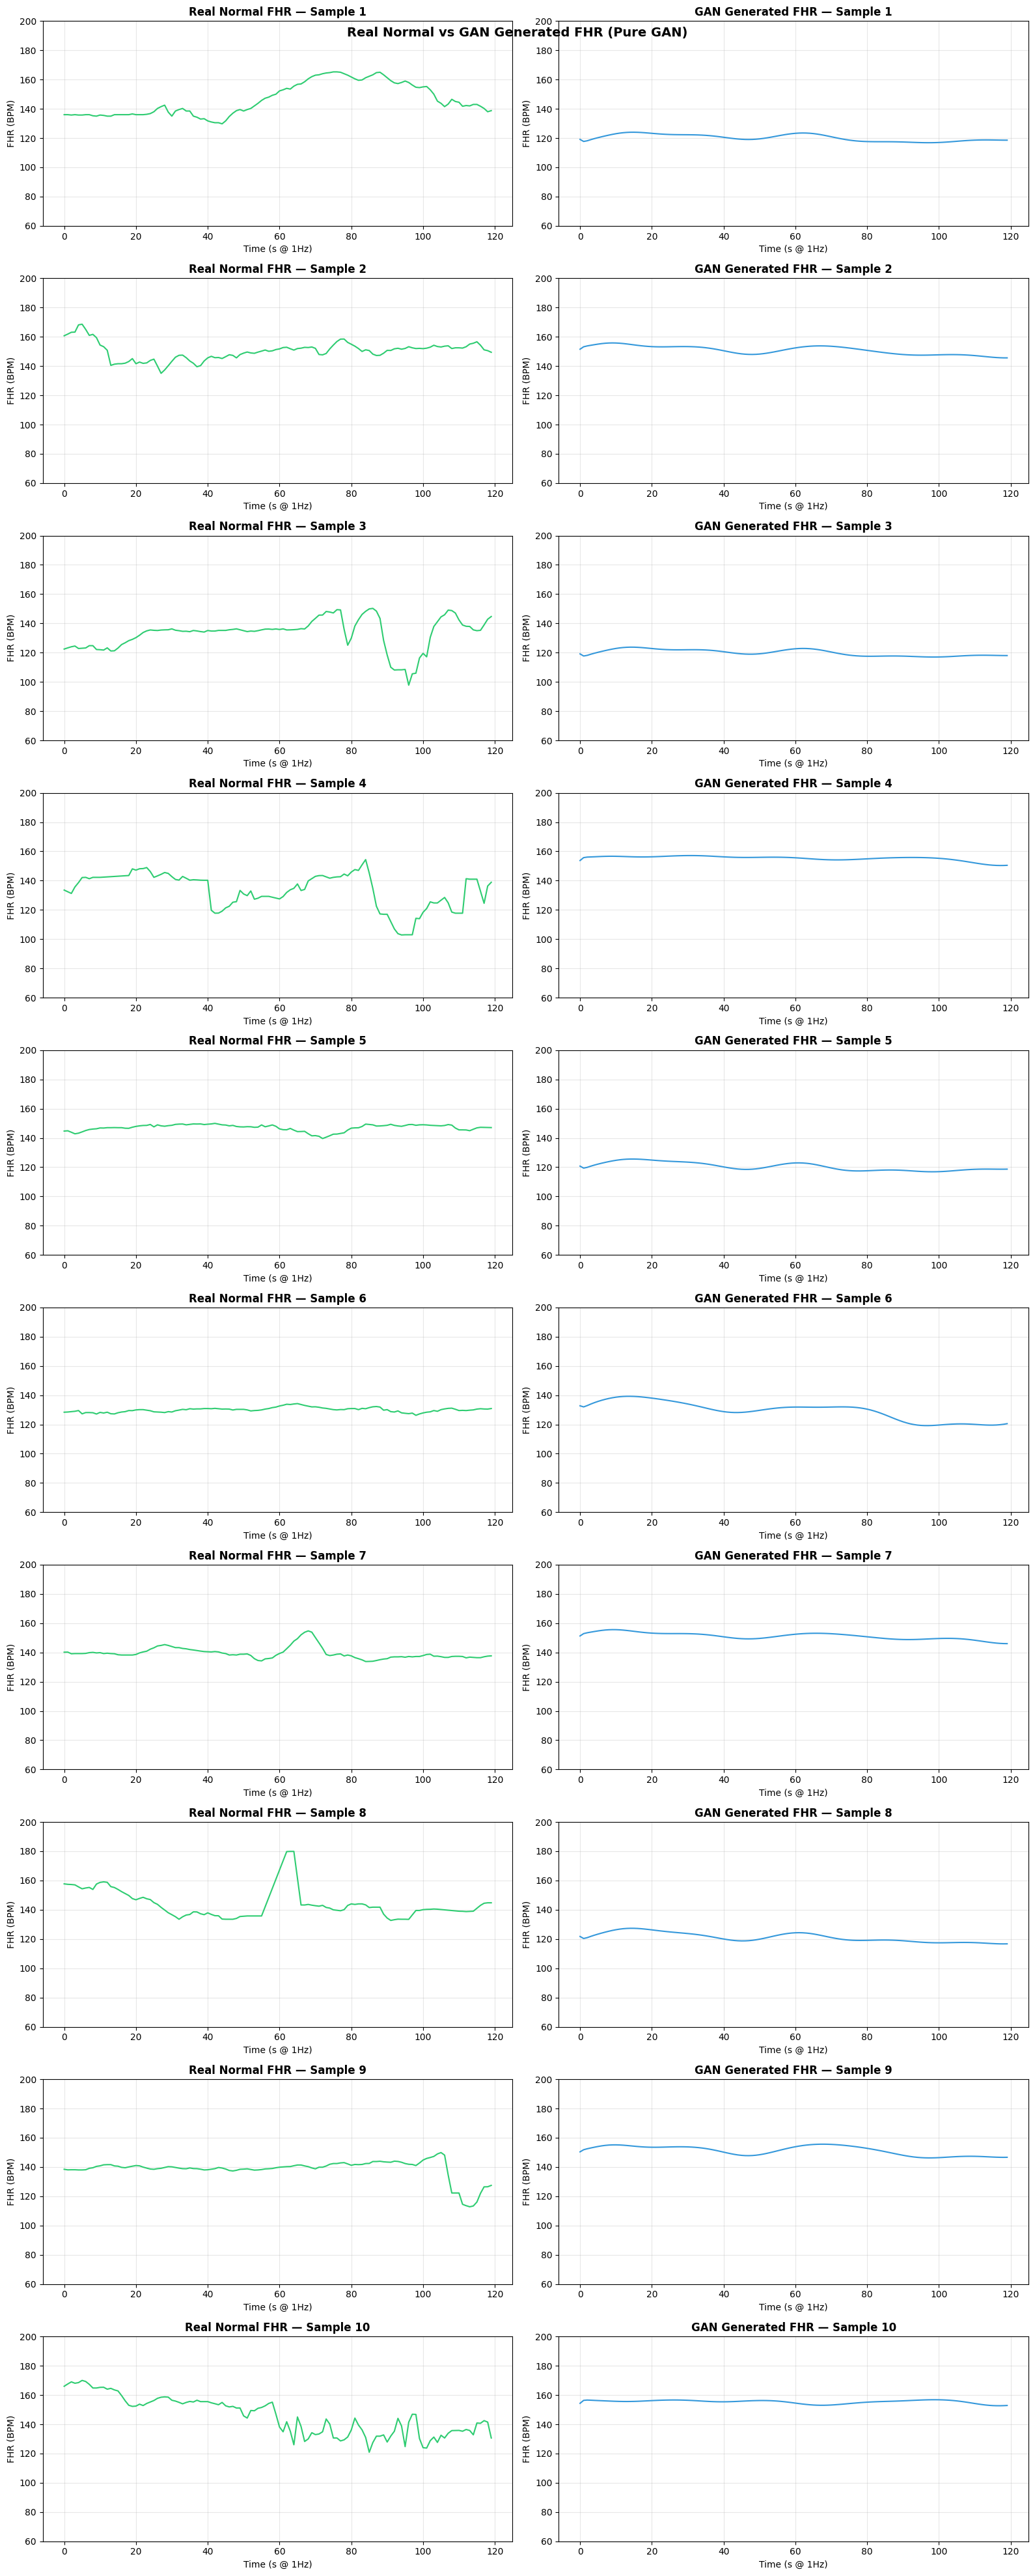

Real 1: Mean=146.15  Std=11.03
GAN  1: Mean=120.13  Std=2.28
Real 2: Mean=150.31  Std=6.10
GAN  2: Mean=150.87  Std=2.90
Real 3: Mean=133.02  Std=10.60
GAN  3: Mean=119.91  Std=2.15
Real 4: Mean=133.49  Std=11.94
GAN  4: Mean=155.28  Std=1.62
Real 5: Mean=147.02  Std=2.26
GAN  5: Mean=120.41  Std=2.70
Real 6: Mean=129.98  Std=1.59
GAN  6: Mean=129.32  Std=6.33
Real 7: Mean=139.54  Std=4.01
GAN  7: Mean=151.21  Std=2.30
Real 8: Mean=144.13  Std=9.98
GAN  8: Mean=121.11  Std=3.14
Real 9: Mean=138.55  Std=6.86
GAN  9: Mean=151.19  Std=3.19
Real 10: Mean=145.75  Std=12.90
GAN  10: Mean=155.35  Std=1.17


In [22]:
# ═══════════════════════════════════════════════════════
# MODULE 5A: 10 Real Normal vs 10 GAN Generated
#             Pure GAN output — no manual noise
# ═══════════════════════════════════════════════════════
noise_viz    = np.random.normal(0, 1, (10, LATENT_DIM))          # ← 2 → 10
fake_lat_viz = generator.predict(noise_viz, verbose=0) * Z_std + Z_mean
fake_seq_viz = decoder_model.predict(fake_lat_viz, verbose=0)
fake_bpm_viz = scaler_fhr.inverse_transform(
    fake_seq_viz[:, :, 0].reshape(-1, 1)).reshape(10, SEQ_LEN)   # ← 2 → 10

X_normal_v   = X_seq[y_seq == 0]
real_bpm_viz = scaler_fhr.inverse_transform(
    X_normal_v[np.random.randint(0, len(X_normal_v), 10)][:, :, 0].reshape(-1, 1)  # ← 2 → 10
).reshape(10, SEQ_LEN)                                            # ← 2 → 10

fig, axes = plt.subplots(10, 2, figsize=(16, 40))                 # ← (2,2) → (10,2), height 8→40

for i in range(10):
    axes[i, 0].plot(real_bpm_viz[i], color='#2ecc71', linewidth=1.5)
    axes[i, 0].set_title(f'Real Normal FHR — Sample {i+1}', fontweight='bold')
    axes[i, 0].set_ylabel('FHR (BPM)'); axes[i, 0].set_ylim(60, 200)
    axes[i, 0].set_xlabel('Time (s @ 1Hz)'); axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(fake_bpm_viz[i], color='#3498db', linewidth=1.5)
    axes[i, 1].set_title(f'GAN Generated FHR — Sample {i+1}', fontweight='bold')
    axes[i, 1].set_ylabel('FHR (BPM)'); axes[i, 1].set_ylim(60, 200)
    axes[i, 1].set_xlabel('Time (s @ 1Hz)'); axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Real Normal vs GAN Generated FHR (Pure GAN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_real_vs_gan_pure.png'), dpi=150)
plt.show()

for i in range(10):
    print(f"Real {i+1}: Mean={real_bpm_viz[i].mean():.2f}  Std={real_bpm_viz[i].std():.2f}")
    print(f"GAN  {i+1}: Mean={fake_bpm_viz[i].mean():.2f}  Std={fake_bpm_viz[i].std():.2f}")

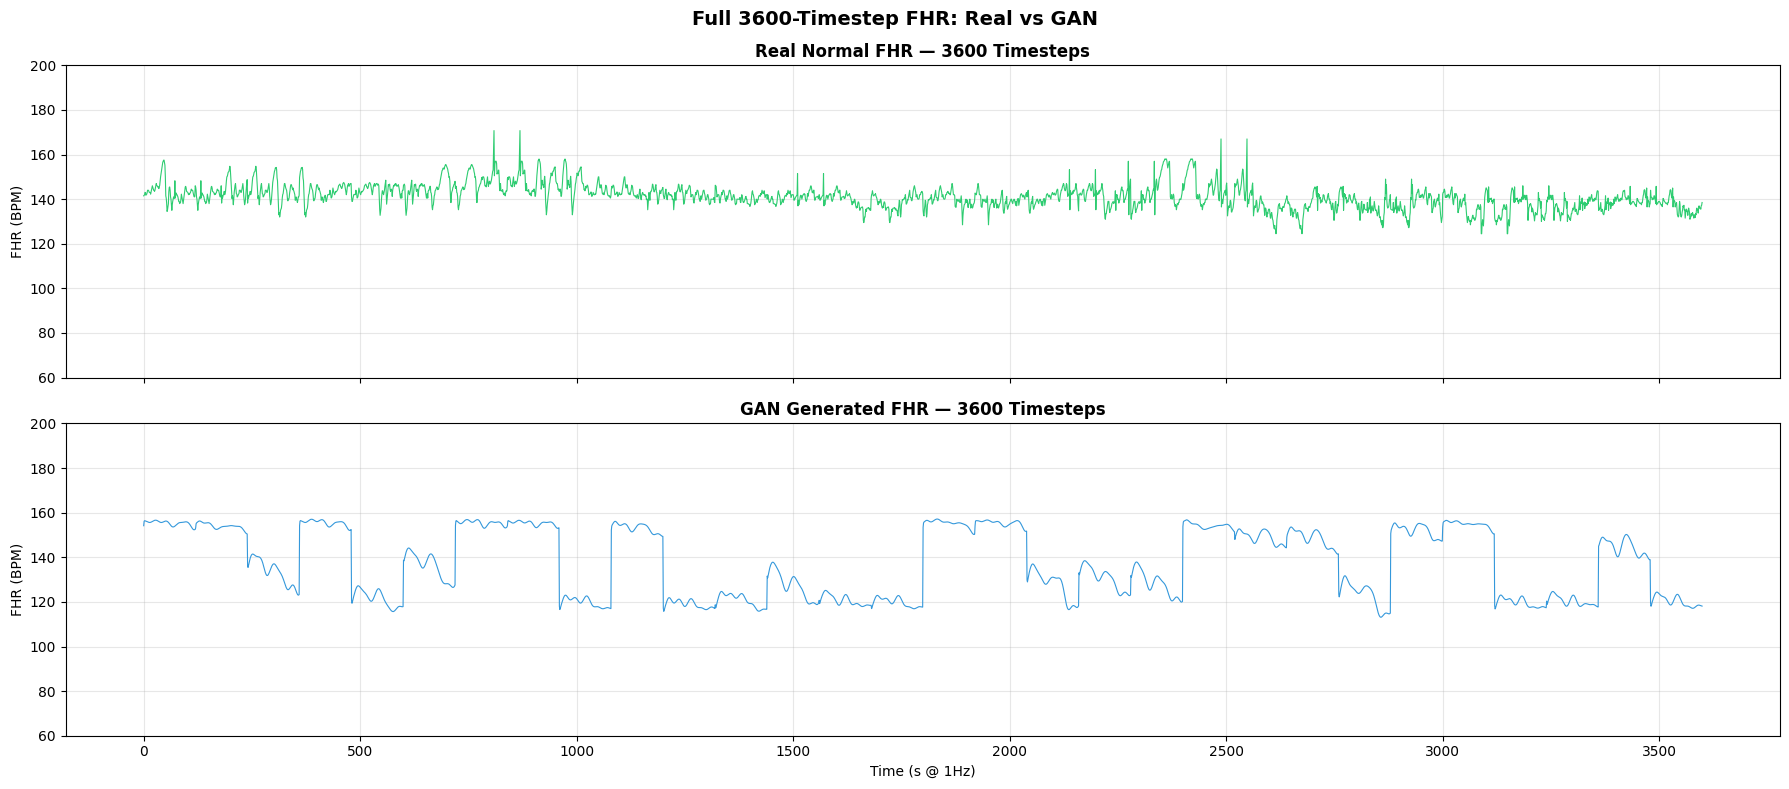

Real — Mean: 141.25  Std: 5.37
GAN  — Mean: 137.66  Std: 15.41


In [23]:
# ═══════════════════════════════════════════════════════
# MODULE 5B: FULL 3600-TIMESTEP SIGNAL — Real vs GAN
# ═══════════════════════════════════════════════════════
N_SEGS        = 30
noise_long    = np.random.normal(0, 1, (N_SEGS, LATENT_DIM))
fake_lat_long = generator.predict(noise_long, verbose=0) * Z_std + Z_mean
fake_seq_long = decoder_model.predict(fake_lat_long, verbose=0)
fake_bpm_long = scaler_fhr.inverse_transform(
    fake_seq_long[:, :, 0].reshape(-1, 1)).reshape(N_SEGS, SEQ_LEN).flatten()

X_normal_v2   = X_seq[y_seq == 0]
real_bpm_long = scaler_fhr.inverse_transform(
    X_normal_v2[:N_SEGS, :, 0].reshape(-1, 1)).reshape(N_SEGS, SEQ_LEN).flatten()

t = np.arange(len(fake_bpm_long))
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)
axes[0].plot(t, real_bpm_long, color='#2ecc71', linewidth=0.8)
axes[0].set_title('Real Normal FHR — 3600 Timesteps', fontweight='bold')
axes[0].set_ylabel('FHR (BPM)'); axes[0].set_ylim(60, 200); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, fake_bpm_long, color='#3498db', linewidth=0.8)
axes[1].set_title('GAN Generated FHR — 3600 Timesteps', fontweight='bold')
axes[1].set_ylabel('FHR (BPM)'); axes[1].set_xlabel('Time (s @ 1Hz)')
axes[1].set_ylim(60, 200); axes[1].grid(True, alpha=0.3)

plt.suptitle('Full 3600-Timestep FHR: Real vs GAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_gan_3600.png'), dpi=150)
plt.show()
print(f"Real — Mean: {real_bpm_long.mean():.2f}  Std: {real_bpm_long.std():.2f}")
print(f"GAN  — Mean: {fake_bpm_long.mean():.2f}  Std: {fake_bpm_long.std():.2f}")


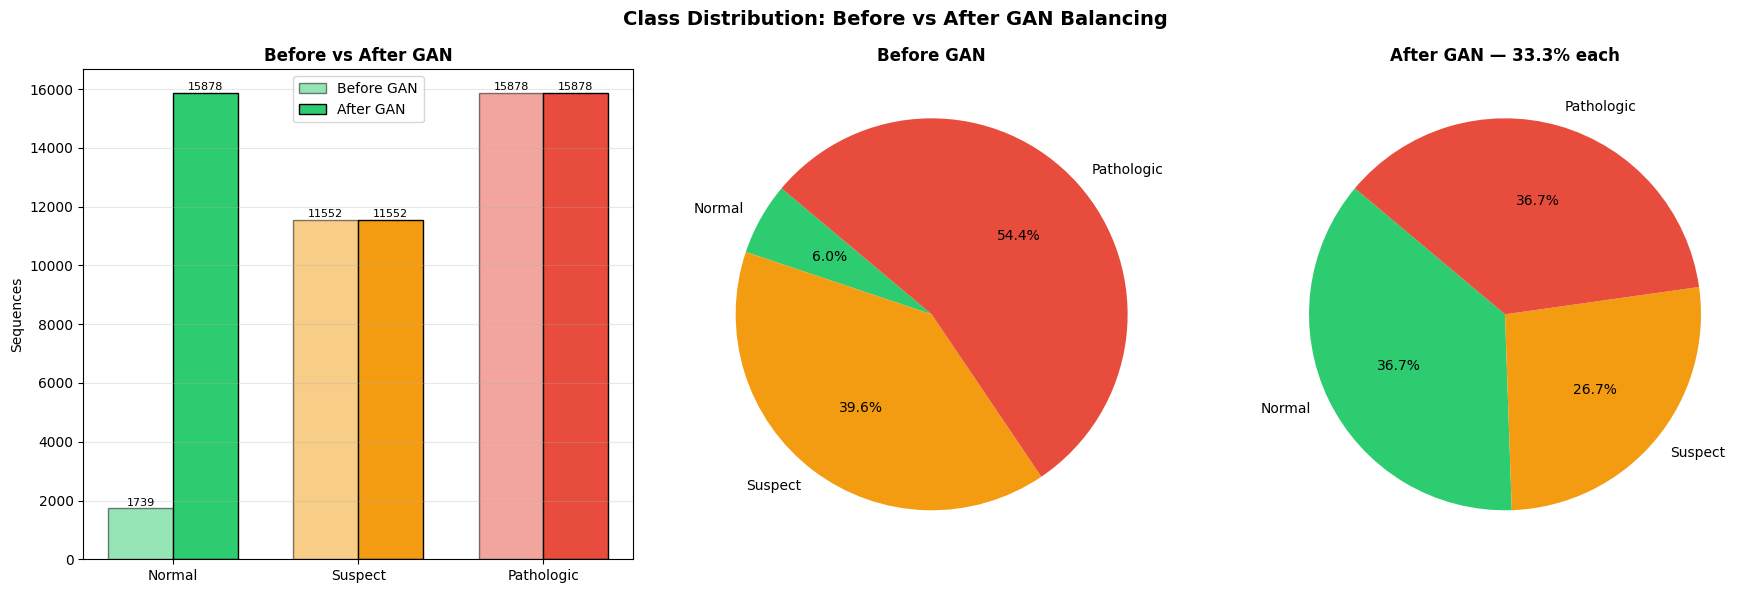

In [24]:
# ═══════════════════════════════════════════════════════
# MODULE 5C: CLASS DISTRIBUTION — Before vs After GAN
# ═══════════════════════════════════════════════════════
counts_before = [int(np.sum(y_seq      == i)) for i in range(3)]
counts_after  = [int(np.sum(y_combined == i)) for i in range(3)]
labels_names  = ['Normal', 'Suspect', 'Pathologic']
colors        = ['#2ecc71', '#f39c12', '#e74c3c']
x, w          = np.arange(3), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bars1 = axes[0].bar(x - w/2, counts_before, w, label='Before GAN',
                    color=colors, alpha=0.5, edgecolor='black')
bars2 = axes[0].bar(x + w/2, counts_after,  w, label='After GAN',
                    color=colors, alpha=1.0, edgecolor='black')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 str(int(bar.get_height())), ha='center', fontsize=8)
axes[0].set_title('Before vs After GAN', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_names)
axes[0].set_ylabel('Sequences'); axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie(counts_before, labels=labels_names, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Before GAN', fontweight='bold')

axes[2].pie(counts_after,  labels=labels_names, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[2].set_title('After GAN — 33.3% each', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After GAN Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_class_balanced.png'), dpi=150)
plt.show()


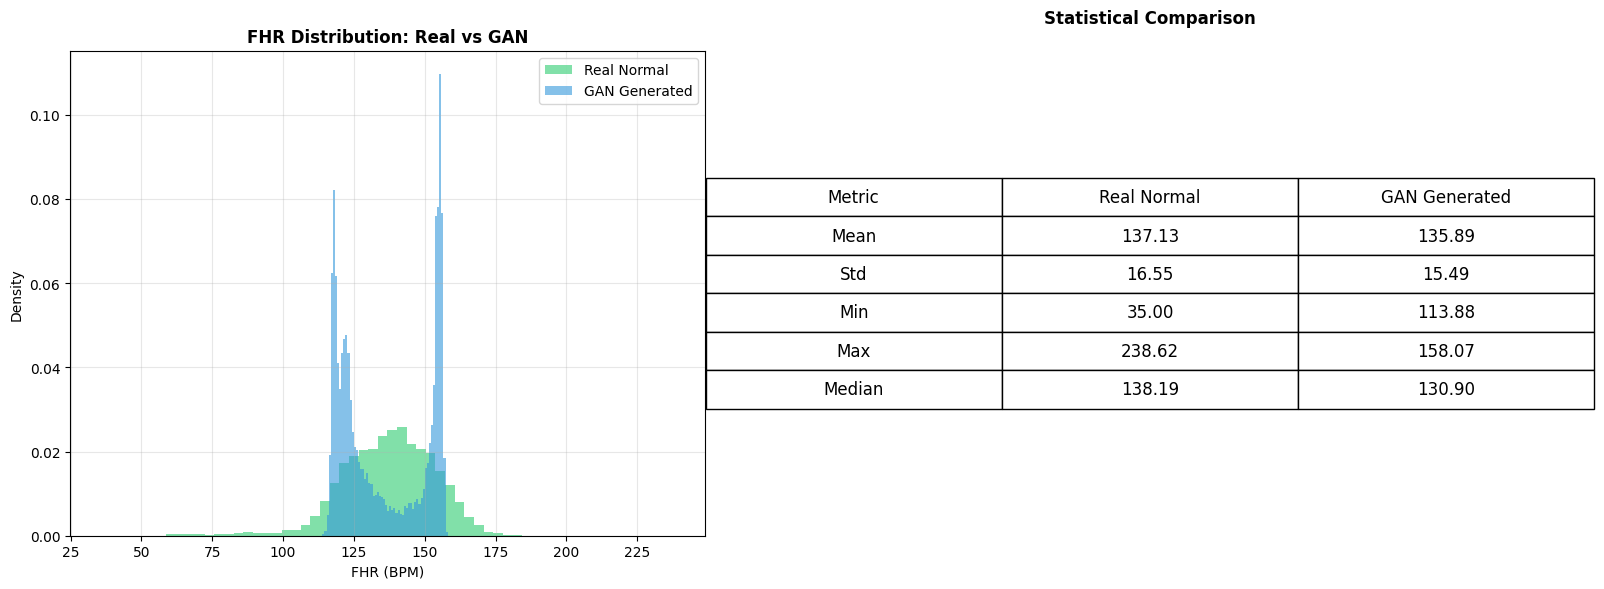

Std ratio (fake/real): 0.936  (target: 0.8–1.2)
Note: AE-GAN compresses latent variability by design (MSE loss).


In [25]:
# ═══════════════════════════════════════════════════════
# MODULE 5D: FHR DISTRIBUTION HISTOGRAM + STATS TABLE
# ═══════════════════════════════════════════════════════
noise200     = np.random.normal(0, 1, (200, LATENT_DIM))
fake_lat200  = generator.predict(noise200, verbose=0) * Z_std + Z_mean
fake_seqs200 = decoder_model.predict(fake_lat200, verbose=0)
fake_bpm200  = scaler_fhr.inverse_transform(fake_seqs200[:, :, 0].reshape(-1, 1)).flatten()

X_normal_all = X_seq[y_seq == 0]
real_bpm_all = scaler_fhr.inverse_transform(X_normal_all[:, :, 0].reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(real_bpm_all, bins=60, alpha=0.6, color='#2ecc71', label='Real Normal', density=True)
axes[0].hist(fake_bpm200,  bins=60, alpha=0.6, color='#3498db', label='GAN Generated', density=True)
axes[0].set_xlabel('FHR (BPM)'); axes[0].set_ylabel('Density')
axes[0].set_title('FHR Distribution: Real vs GAN', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

metrics    = ['Mean', 'Std', 'Min', 'Max', 'Median']
real_stats = [f'{np.mean(real_bpm_all):.2f}', f'{np.std(real_bpm_all):.2f}',
              f'{np.min(real_bpm_all):.2f}',   f'{np.max(real_bpm_all):.2f}',
              f'{np.median(real_bpm_all):.2f}']
fake_stats = [f'{np.mean(fake_bpm200):.2f}',  f'{np.std(fake_bpm200):.2f}',
              f'{np.min(fake_bpm200):.2f}',    f'{np.max(fake_bpm200):.2f}',
              f'{np.median(fake_bpm200):.2f}']

axes[1].axis('off')
tbl = axes[1].table(
    cellText=list(zip(metrics, real_stats, fake_stats)),
    colLabels=['Metric', 'Real Normal', 'GAN Generated'],
    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(12); tbl.scale(1.4, 2.2)
axes[1].set_title('Statistical Comparison', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_fhr_stats.png'), dpi=150)
plt.show()

std_ratio = np.std(fake_bpm200) / np.std(real_bpm_all)
print(f"Std ratio (fake/real): {std_ratio:.3f}  (target: 0.8–1.2)")
print("Note: AE-GAN compresses latent variability by design (MSE loss).")
